# Results FCBG Connectome Registration

Visualisation of metabolite concentration maps (MRSI) overlaid on the T1w UNI-DEN background.


In [1]:
%run -i main.py

  [sum] sub-01: saved sub-01_ses-01_acq-OrigRes_desc-AllMetabSum_mrsi.nii.gz  (38 maps summed)
  [t1w-ds] sub-01: already exists  sub-01_ses-01_acq-MRSIres_T1w.nii.gz
  [reg] saved registered MRSI: /Users/user/FCBG_project_Connectome_registraction/Code/FCBG_project_Connectome_registraction/data/output/sub-01_ses-01_acq-MRSIres_desc-Registered_mrsi.nii.gz
  [reg] saved registered MRSI: /Users/user/FCBG_project_Connectome_registraction/Code/FCBG_project_Connectome_registraction/data/output/sub-01_ses-01_acq-FullRes_desc-Registered_mrsi.nii.gz
  [reg] saved registered MRSI: /Users/user/FCBG_project_Connectome_registraction/Code/FCBG_project_Connectome_registraction/data/output/sub-01_ses-01_acq-MRSIres_desc-RegisteredSum_mrsi.nii.gz
  [reg] applying pre-computed transforms (skipping optimisation)
  [reg] saved registered MRSI: /Users/user/FCBG_project_Connectome_registraction/Code/FCBG_project_Connectome_registraction/data/output/sub-01_ses-01_acq-MRSIres_desc-SumViaBestSNRXfm_mrsi.nii.gz

In [2]:
from data_utils import (
    img_info,
    rank_metabolites_by_snr,
    segment_t1w,segment_t1w_atlas)
from registration_utils import (
    register_t1w_to_mrsi_weighted,
    apply_transform_to_metabolite,
    apply_transform_all_metabolites,
    compute_registration_metrics,
    compute_image_quality_metrics,
)
from plot_utils import (
    set_figures_dir,
    plot_single_overlay,
    plot_support_mask,
    plot_coverage_grid,
    plot_mrsi_mosaic,
    plot_mrsi_combined,
    build_coverage_widget,
    plot_t1w_mrs_comparison,
    plot_snr_ranking,
    plot_water_mask_comparison,
    plot_registration_comparison,
    plot_registration_methods_comparison,
    plot_registration_target_comparison,
    plot_coverage_registration_comparison,
    compare_registration_coverage,
    plot_sum_registration_comparison,
    plot_inverse_registration_panels,
    compare_inverse_registration_pair,
    plot_total_pipeline_comparison,
    plot_total_pipeline_mask_comparison,
    plot_registration_metrics,
    plot_pipeline_metrics_comparison,
    plot_final_registration_mosaic,
    plot_segmentation,
    plot_atlas_segmentation,
    plot_mrsi_sum_mask_contours,
    plot_mask_coverage_comparaison,
    plot_tissue_metric_comparison,
    plot_tissue_slope_comparison,
)

FIGURES_DIR = os.path.join(os.path.dirname(OUTPUT_DIR), "figures")
set_figures_dir(FIGURES_DIR)
print(f"Figures will be saved to: {FIGURES_DIR}")

Figures will be saved to: /Users/user/FCBG_project_Connectome_registraction/Code/FCBG_project_Connectome_registraction/data/figures


## 1 – Sanity check: image shapes & voxel sizes

In [3]:

img_info(t1w_img,     "T1w UNI-DEN")
img_info(mrs_example, f"MRS – {mrs_files[0]}")

T1w UNI-DEN
  shape      : (224, 272, 288)
  voxel size : [0.8   0.799 0.799] mm
  dtype      : int16

MRS – sub-01_ses-01_acq-OrigRes_desc-2HG_mrsi.nii.gz
  shape      : (74, 74, 37)
  voxel size : [2.973 2.973 2.973] mm
  dtype      : float32



## 2 – Single metabolite overlay on T1w

`plot_single_overlay` canonicalizes orientations, resamples MRSI to T1 grid, and plots 3 orthogonal views.  
Change `METABOLITE` to any label available in `mrs_files`.

Showing: sub-01_ses-01_acq-OrigRes_desc-NAA_mrsi.nii.gz


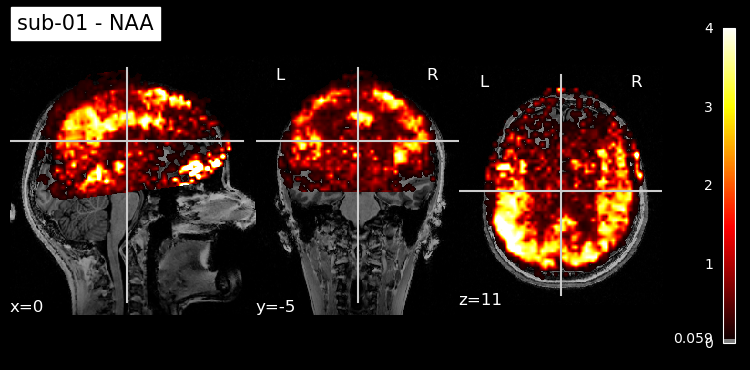

  Brain coverage: 18.6%


In [4]:
METABOLITE = "NAA"   # change to any metabolite label (e.g. "Cr", "Glu", "GABA")
match = [f for f in mrs_files if f"desc-{METABOLITE}_" in f]
if not match:
    print(f"No file found for metabolite '{METABOLITE}'")
else:
    print(f"Showing: {match[0]}")
    plot_single_overlay(match[0], T1W_PATH, MRS_DIR, subj=SUBJ)


## 3 – Coverage check:

Overlay several metabolite maps on the T1w in a single figure  so we can directly compare spatial coverage across metabolites.

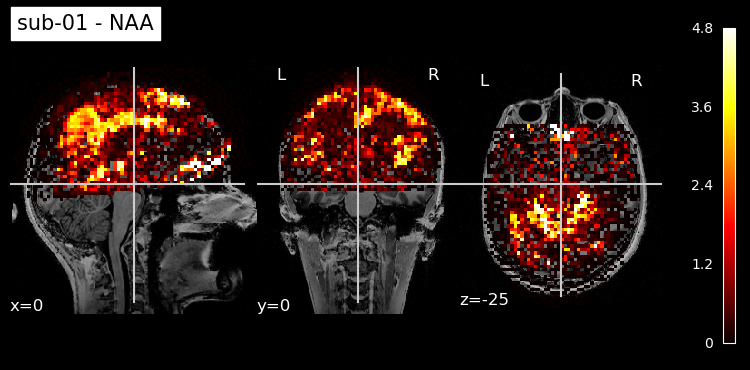

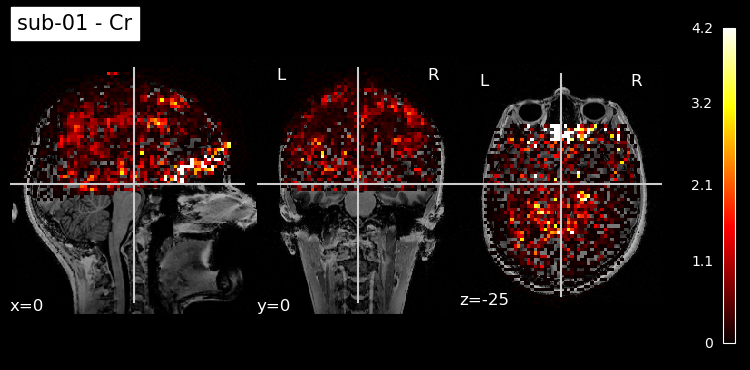

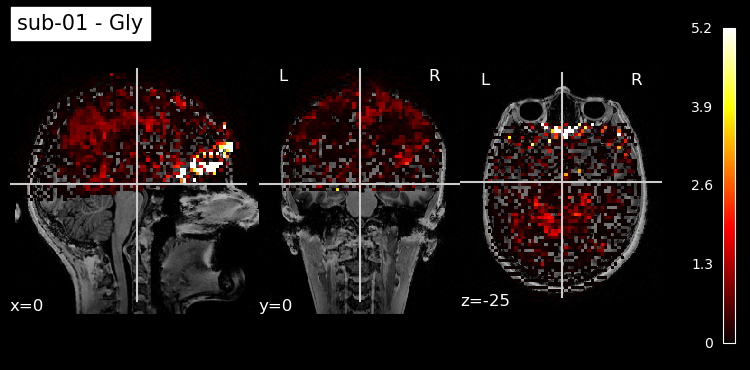

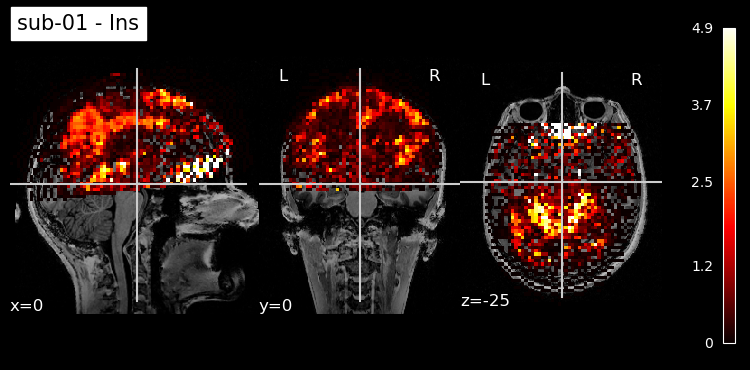

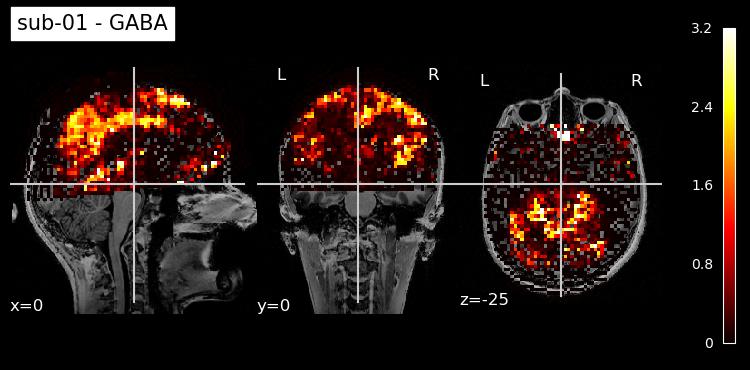

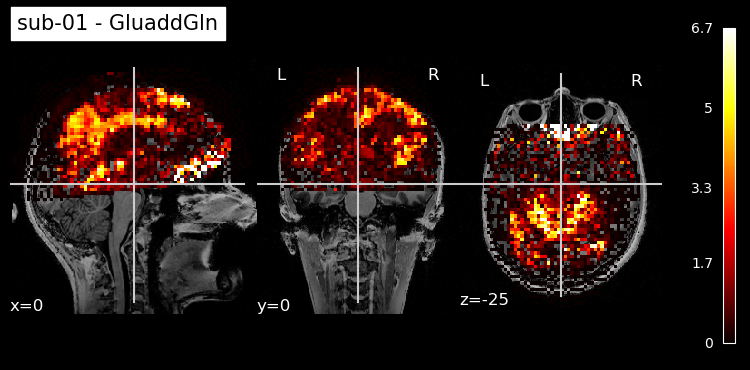

In [5]:
COVERAGE_MAPS = [
    f"{SUBJ}_{SES}_acq-OrigRes_desc-NAA_mrsi.nii.gz",
    f"{SUBJ}_{SES}_acq-OrigRes_desc-Cr_mrsi.nii.gz",
    f"{SUBJ}_{SES}_acq-OrigRes_desc-Gly_mrsi.nii.gz",
    f"{SUBJ}_{SES}_acq-OrigRes_desc-Ins_mrsi.nii.gz",
    f"{SUBJ}_{SES}_acq-OrigRes_desc-GABA_mrsi.nii.gz",
    f"{SUBJ}_{SES}_acq-OrigRes_desc-GluaddGln_mrsi.nii.gz",
]
plot_coverage_grid(COVERAGE_MAPS, MRS_DIR, T1W_PATH, subj=SUBJ)


## 5 – Support mask: pure binary spatial footprint

Binary mask of where signal exists, overlaid on the T1w.


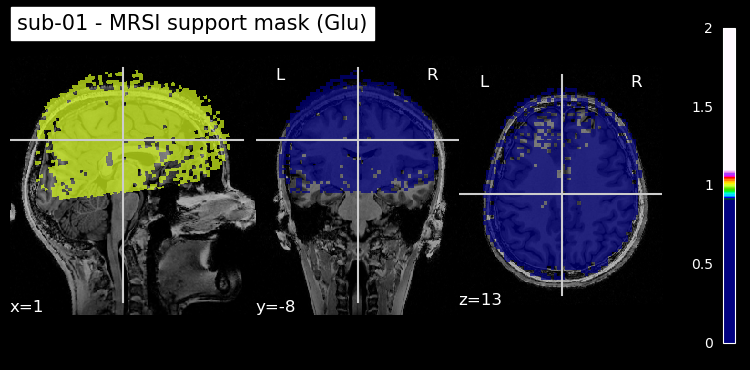

  Brain coverage: 14.1%


0.1414142215021152

In [6]:
plot_support_mask(
    f"{SUBJ}_{SES}_acq-OrigRes_desc-Glu_mrsi.nii.gz",
    T1W_PATH, MRS_DIR, subj=SUBJ,
)

## 7 – Sum of all metabolite maps (native MRS space)


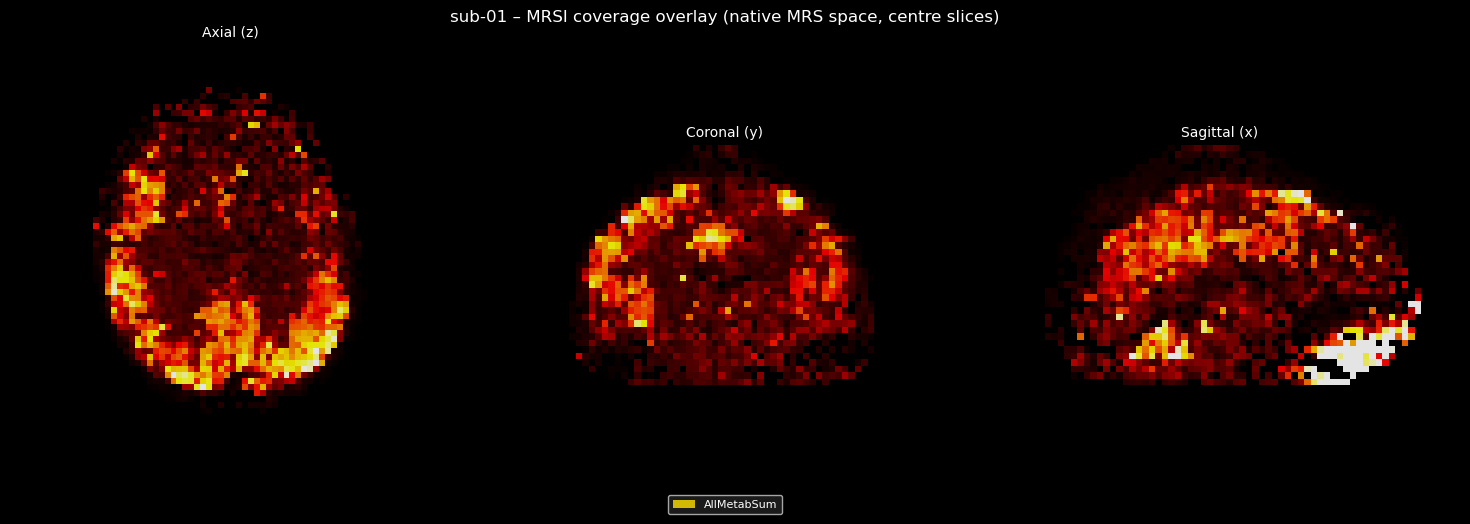

In [7]:

# visualise all 3 orthogonal centre slices side by side
plot_mrsi_combined([SUM_NAME], MRS_DIR, subj=SUBJ, cmaps=["hot"], alpha=0.9)


## 8 – Downsampled T1w at MRSI resolution

The T1w UNI-DEN image is resampled to the exact voxel grid of the MRSI concentration maps.

=== Downsampled T1w ===
T1w @ MRS res  (sub-01_ses-01_acq-MRSIres_T1w.nii.gz)
  shape      : (74, 74, 37)
  voxel size : [2.973 2.973 2.973] mm
  dtype      : float32

MRS ref        (sub-01_ses-01_acq-OrigRes_desc-2HG_mrsi.nii.gz)
  shape      : (74, 74, 37)
  voxel size : [2.973 2.973 2.973] mm
  dtype      : float32



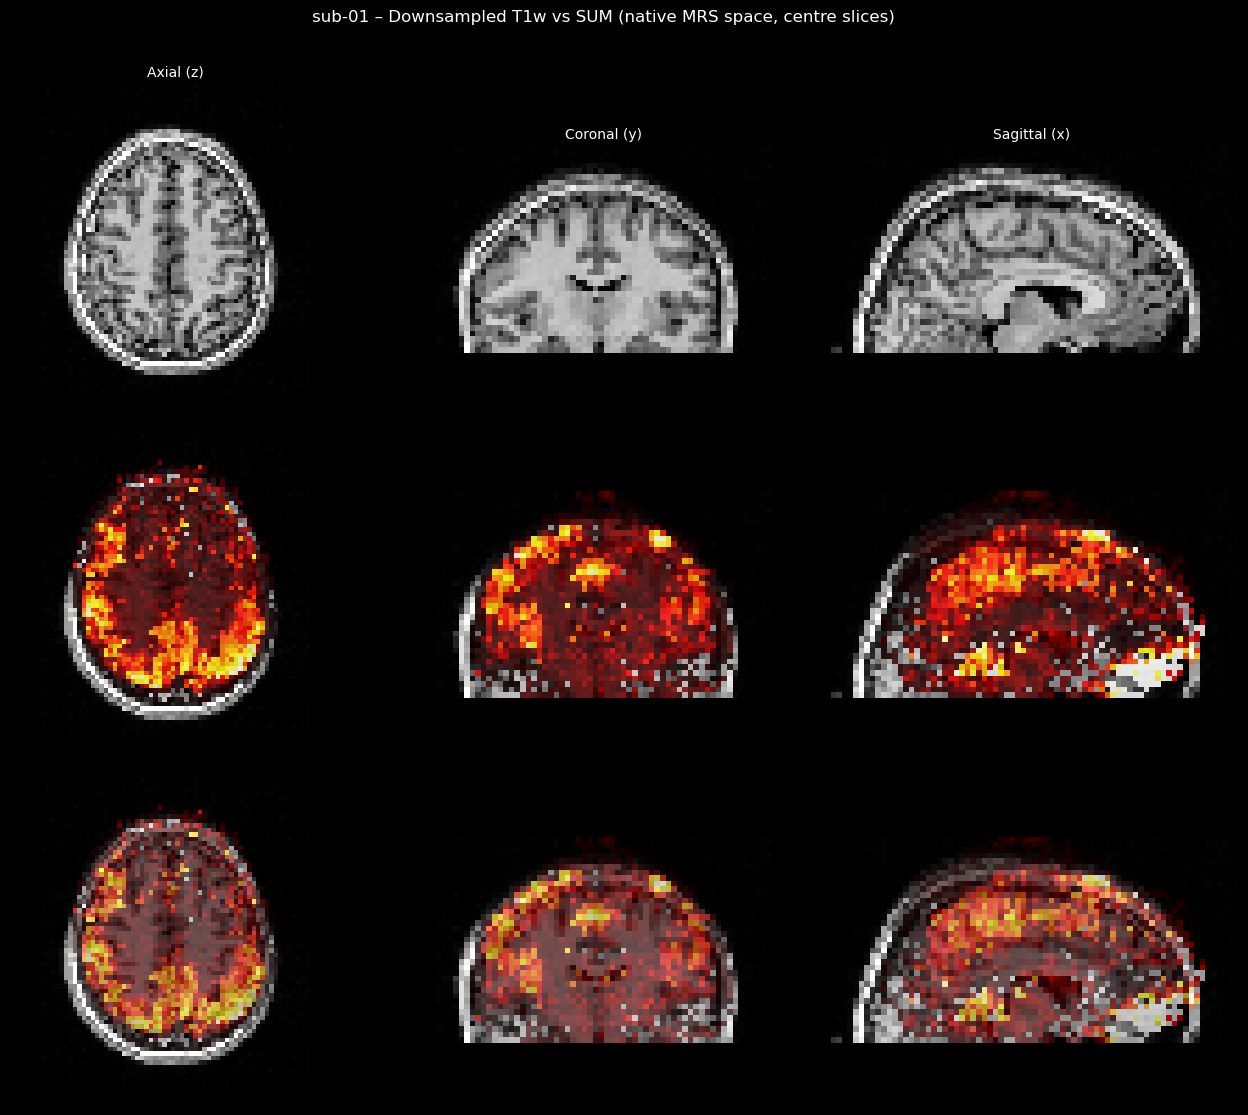

In [8]:

print("=== Downsampled T1w ===")
img_info(t1w_ds_img, f"T1w @ MRS res  ({T1W_DS_NAME})")
img_info(mrs_example, f"MRS ref        ({mrs_files[0]})")

# pick NAA as the representative metabolite for the overlay comparison
_ref_metab = f"{SUBJ}_{SES}_acq-OrigRes_desc-AllMetabSumRAS_mrsi.nii.gz"
import nibabel as nib, os
_mrs_img = nib.load('/Users/user/FCBG_project_Connectome_registraction/Code/FCBG_project_Connectome_registraction/data/output/sub-01_ses-01_acq-OrigRes_desc-AllMetabSumRAS_mrsi.nii.gz')

plot_t1w_mrs_comparison(
    t1w_ds_img,
    _mrs_img,
    subj=SUBJ,
    mrs_label="SUM",
    )


## 9 – Best-SNR metabolite map

All `acq-OrigRes` concentration maps are ranked by their mean VoxelSNR  the scanner derived per voxel SNR map (`desc-VoxelSNR_mrsi`) averaged over the support mask of each metabolite.


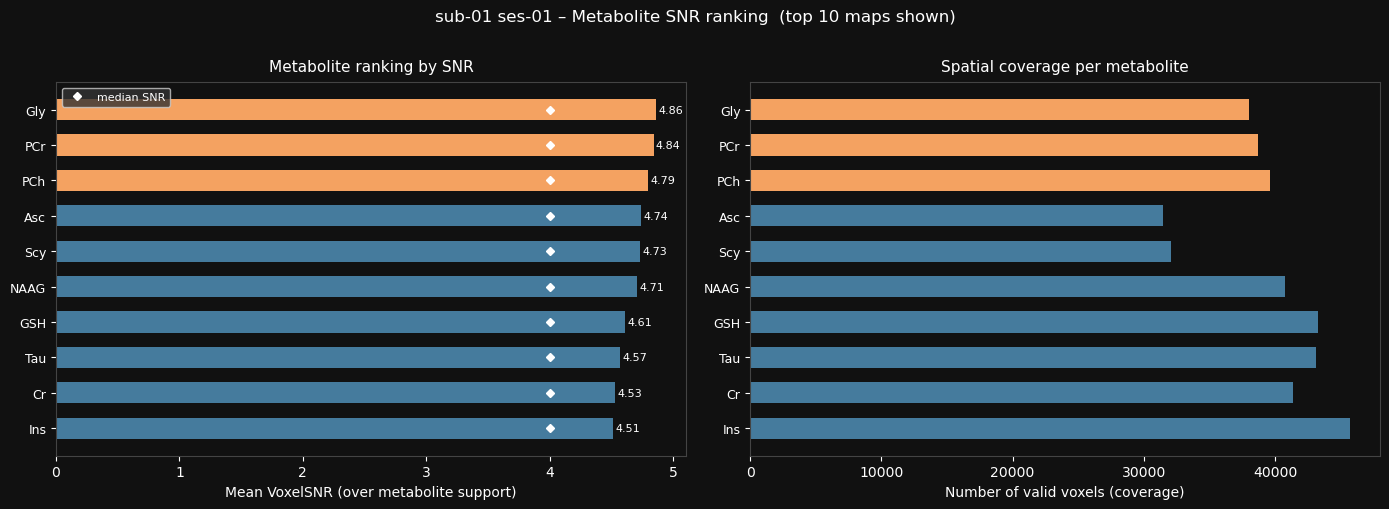


Top-3 metabolites by mean VoxelSNR:
  # 1  Gly                        mean_SNR=4.86  median_SNR=4.00  n_voxels=38,015  CV=9.187
  # 2  PCr                        mean_SNR=4.84  median_SNR=4.00  n_voxels=38,708  CV=4.719
  # 3  PCh                        mean_SNR=4.79  median_SNR=4.00  n_voxels=39,631  CV=2.344


In [9]:
# rank all metabolites by SNR using the scanner-provided VoxelSNR map
snr_records = rank_metabolites_by_snr(MRS_DIR, subj=SUBJ, ses=SES)

# bar chart: mean/median SNR + coverage for the top-20 maps
plot_snr_ranking(snr_records, top_n=10, highlight_best=3)


Best SNR metabolite: Gly  (mean_SNR=4.86)


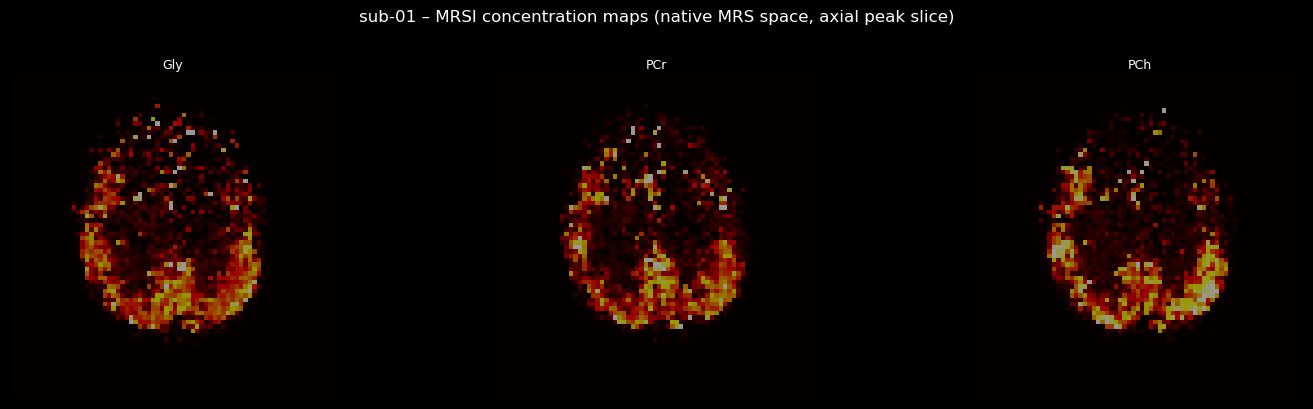

In [10]:
# visualise the best-SNR map and the top-3 together
best = snr_records[0]
top3 = [r["filename"] for r in snr_records[:3]]

print(f"Best SNR metabolite: {best['metabolite']}  (mean_SNR={best['mean_snr']:.2f})")

# mosaic: peak axial slice for each of the top-3 maps
plot_mrsi_mosaic(top3, MRS_DIR, subj=SUBJ, cmap="hot", cols=3)


## 10 – Water mask: raw vs hole-filled comparison



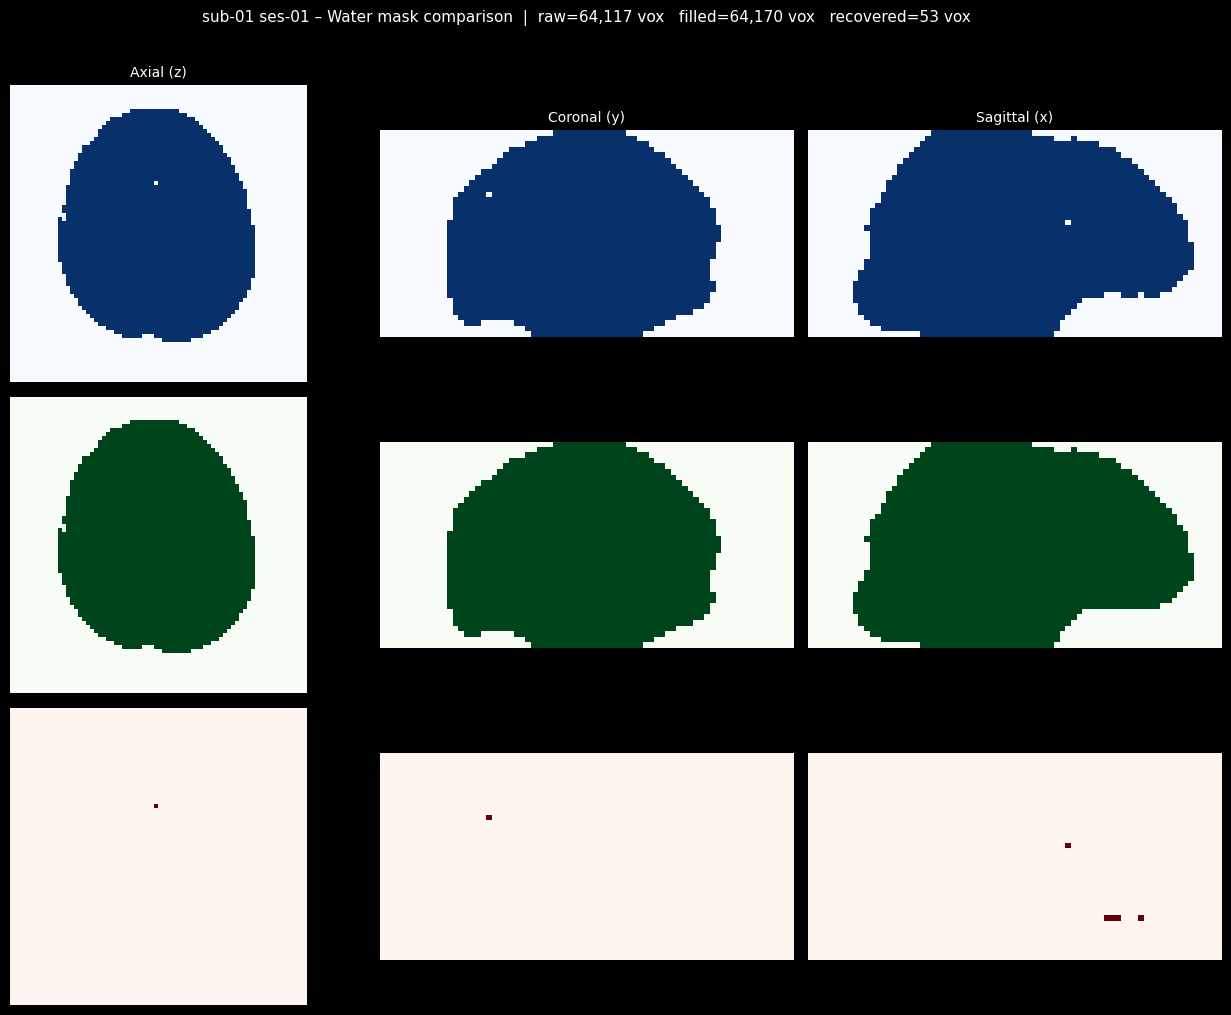

Raw mask voxels   : 64,117
Filled mask voxels: 64,170
Holes recovered   : 53  (0.08% of filled mask)


In [11]:

plot_water_mask_comparison(water_img, water_mask, subj=SUBJ, ses=SES)


## 11 – T1w/MRSI registration: before vs after

The downsampled T1w is masked with the filled water mask and then rigidly registered to the best-SNR MRSI map using ANTsPy. Because both images come from the same subject and session, a rigid transform is used.


Best-SNR metabolite used as registration target: Gly


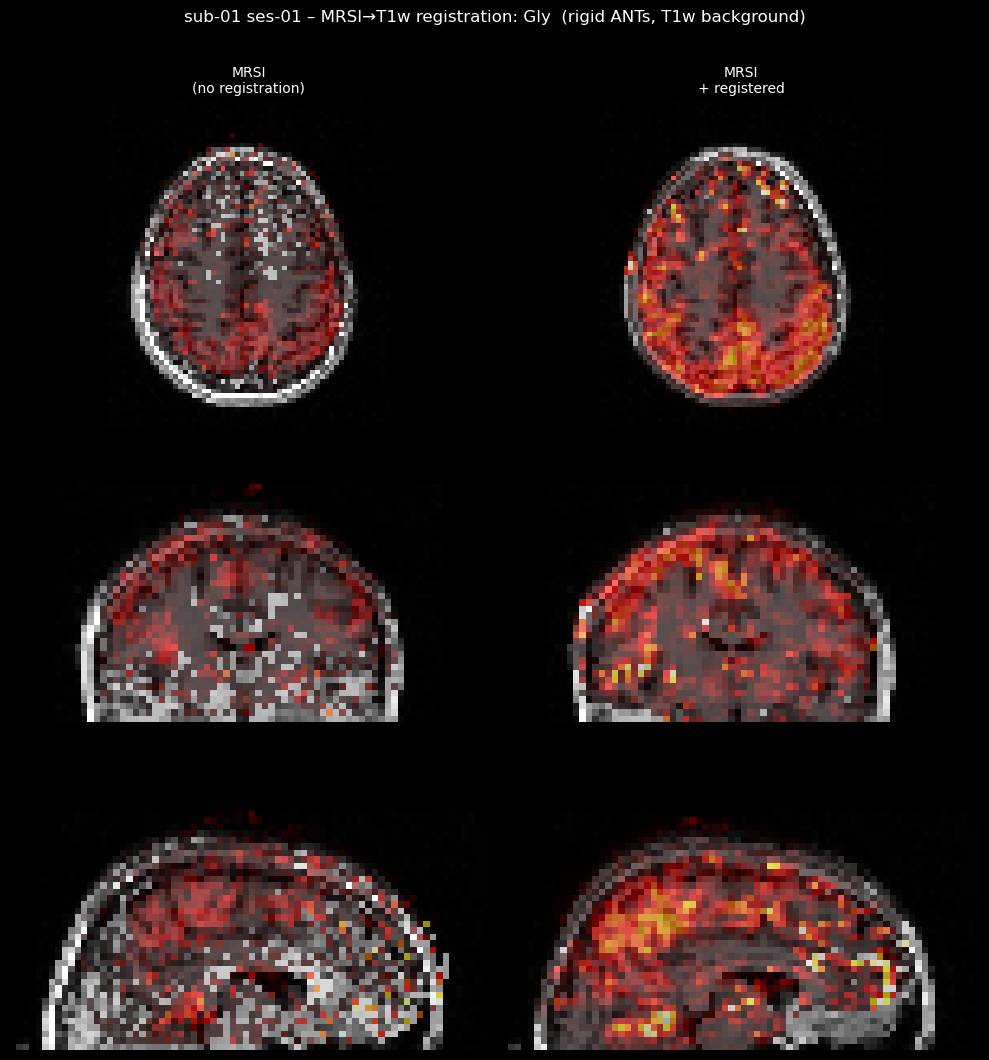

In [12]:

print(f"Best-SNR metabolite used as registration target: {best_mrsi_label}")
plot_registration_comparison(
    t1w_ds_img,
    best_mrsi_img,
    mrsi_reg_ds_img,
    subj=SUBJ,
    ses=SES,
    mrsi_label=best_mrsi_label,
)


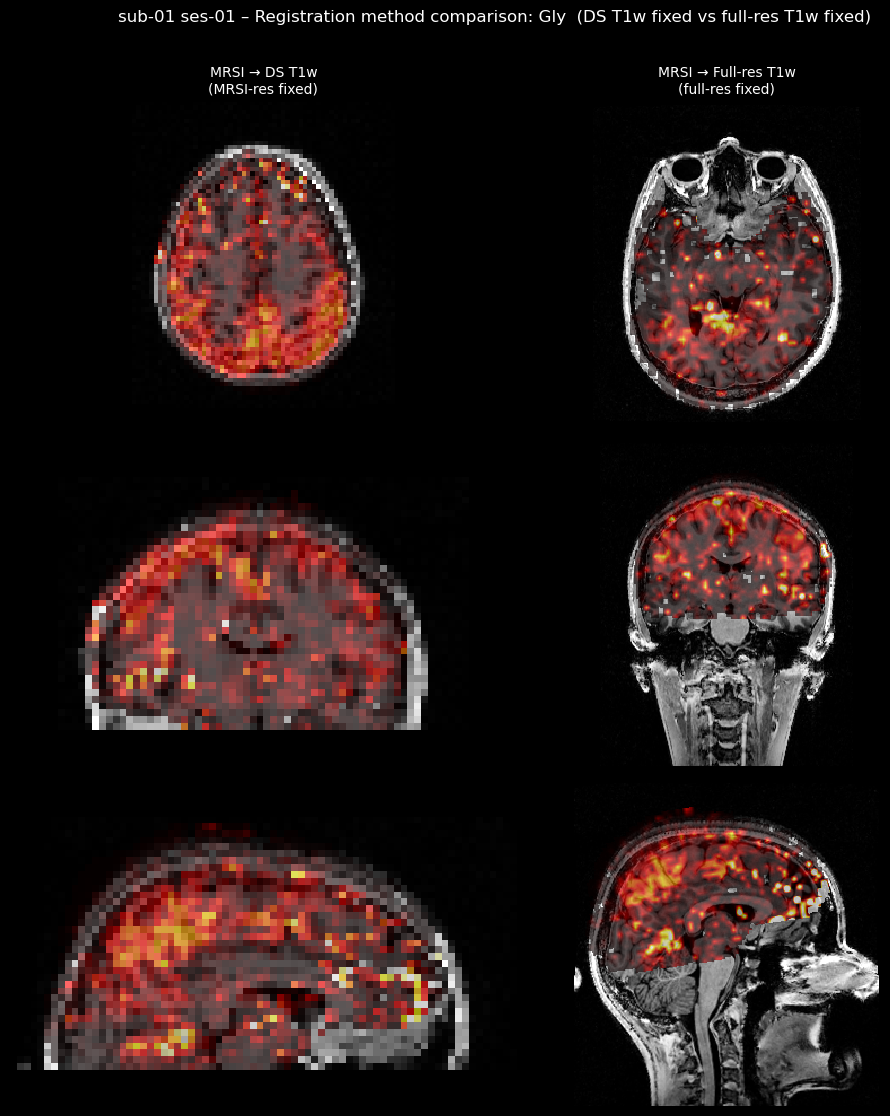

In [13]:

plot_registration_methods_comparison(
    t1w_ds_img,
    t1w_img,
    mrsi_reg_ds_img,
    mrsi_reg_fullres_img,
    subj=SUBJ,
    ses=SES,
    mrsi_label=best_mrsi_label,
)


## 12 – Registration target comparison: best-SNR metabolite vs metabolite sum

Two strategies for choosing the moving image to register to the downsampled T1w (rigid ANTs):

- Left  image = best-SNR metabolite map  
- Right image = voxel-wise sum of all metabolite maps



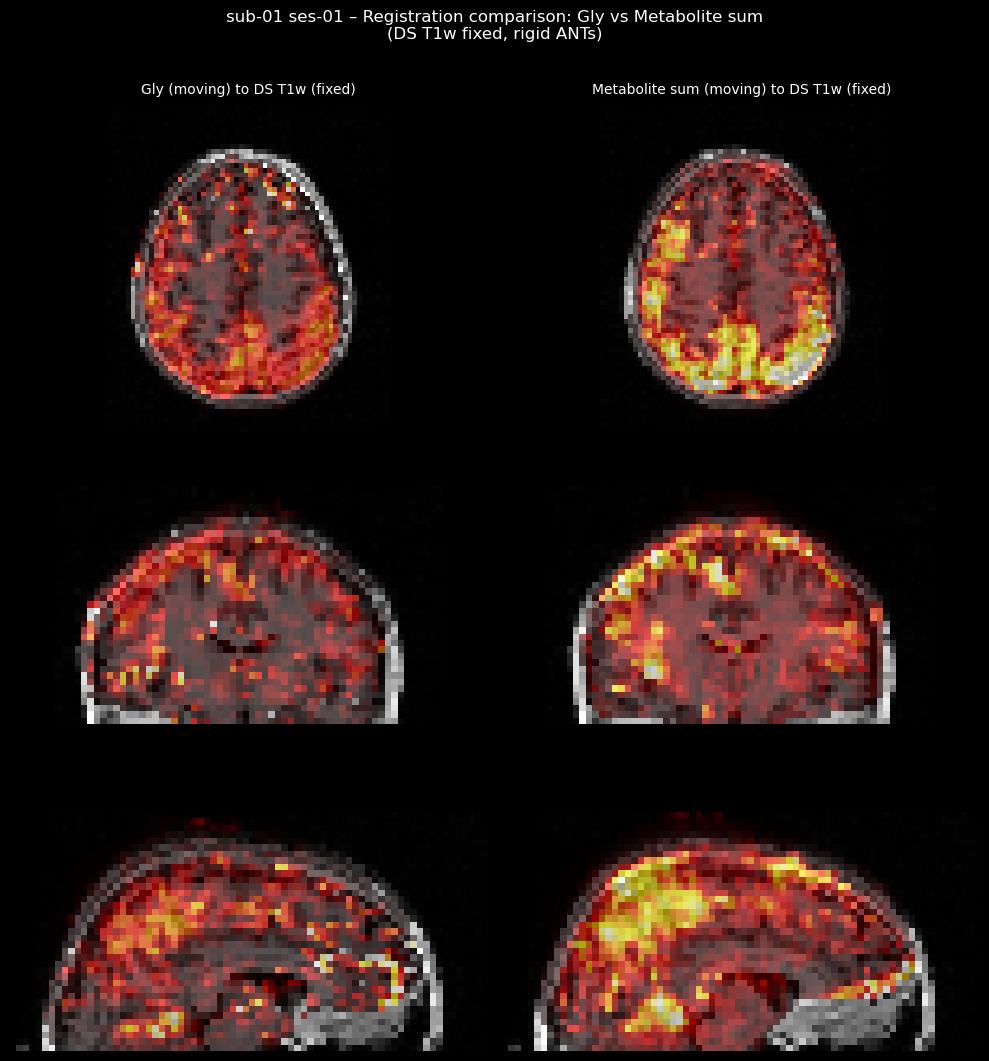

In [14]:

plot_registration_target_comparison(
    t1w_ds_img,
    mrsi_reg_ds_img,
    mrsi_sum_reg_img,
    subj=SUBJ,
    ses=SES,
    bestsnr_label=best_mrsi_label,
)


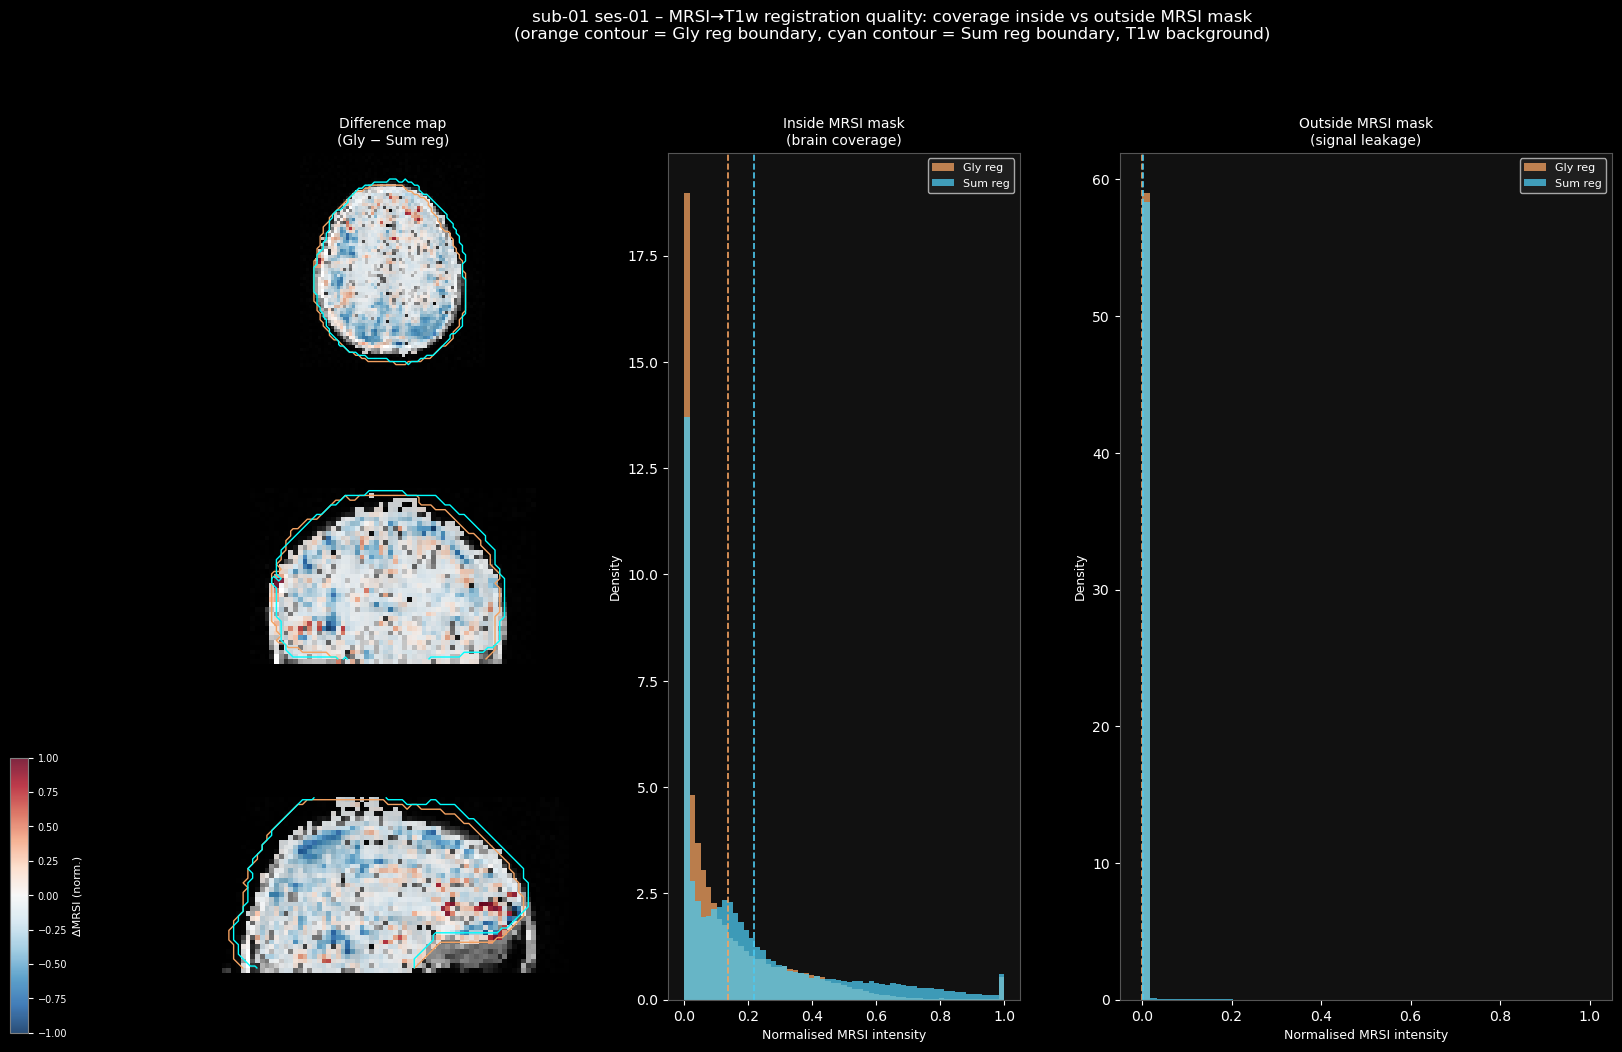

Metric                               Gly reg         Sum reg         Δ (a−b)
────────────────────────────────────────────────────────────────────────────
Mean MRSI in-mask                     0.1361          0.2181         -0.0819
Mean MRSI out-of-mask                 0.0000          0.0015         -0.0015
In/Out SNR ratio              136108479.7430        149.7229  +136108330.0200
% active voxels in-mask              53.7456         68.2633        -14.5177
% active voxels out                   0.0000          0.7189         -0.7189


In [15]:

cov_metrics = compare_registration_coverage(
    t1w_ds_img,
    water_mask,
    best_mrsi_img,
    mrsi_reg_ds_img,
    mrsi_sum_reg_img,
    reg1_transforms,
    reg3_transforms,
    subj=SUBJ,
    ses=SES,
    bestsnr_label=best_mrsi_label,
)


## 13 – Metabolite sum: independent registration vs best-SNR transform reuse

Two ways to bring the gly map into DS T1w space:
- Left independent registration: the gly image is used as the moving image and ANTs solves a new rigid transform optimised specifically for it.
- Right transform reuse: the rigid transform already solved for the sum image is applied directly to the sum, with no re optimisation.


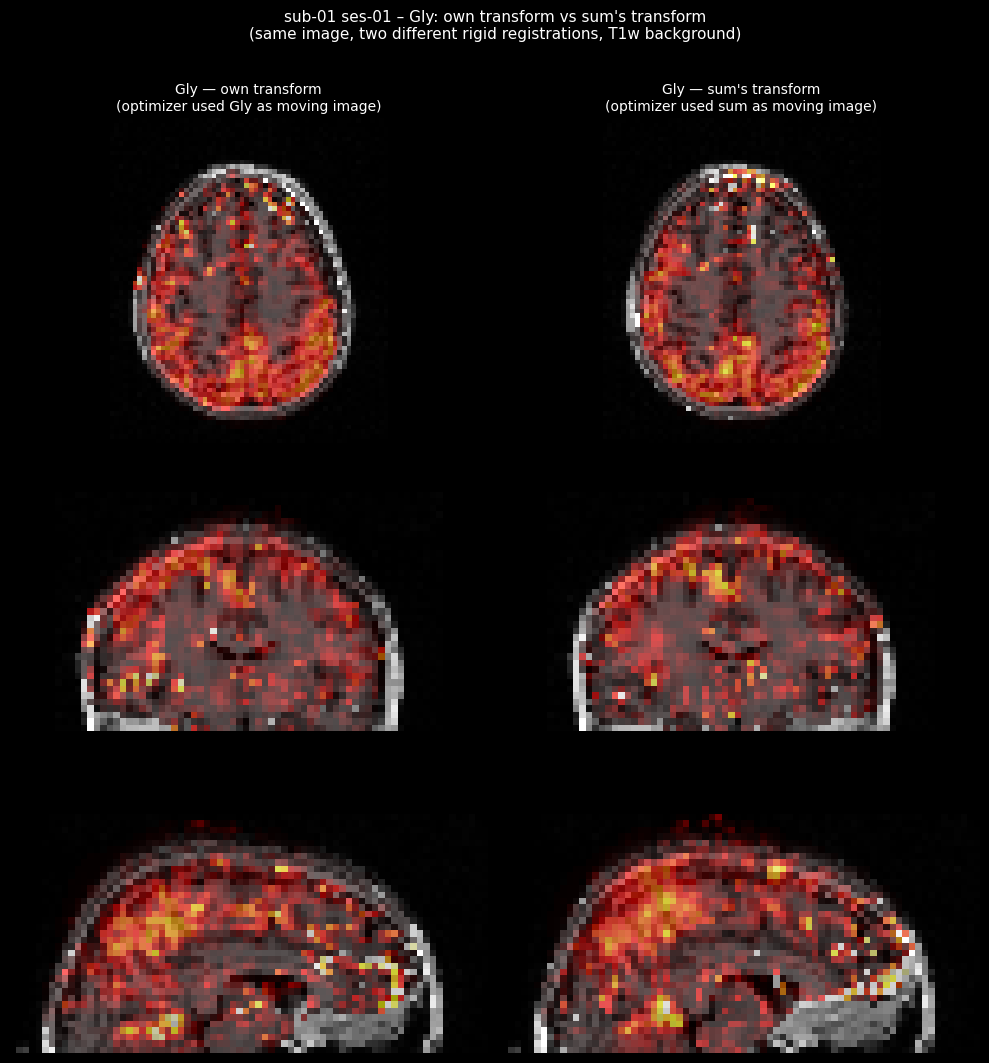

                                   mean in brain   CC with T1w
  ----------------------------------------------------------
  Gly — own transform                     0.1322       -0.0036
  Gly — sum's transform                   0.1325       -0.0051


In [16]:

plot_sum_registration_comparison(
    t1w_ds_img,
    mrsi_reg_ds_img,
    mrsi_gly_via_sum_img,
    subj=SUBJ,
    ses=SES,
    bestsnr_label=best_mrsi_label,
)

## 14 – Coverage-based vs SNR-based registration: three-way comparison

Three ways of placing the Gly map (best-SNR metabolite) and the best-coverage metabolite into DS T1w space, all compared side by side:


Best-coverage metabolite : MM14addLip13aaddLip13baddMM12  (49036 voxels)
Best-SNR (Gly)           : Gly  (38015 voxels)


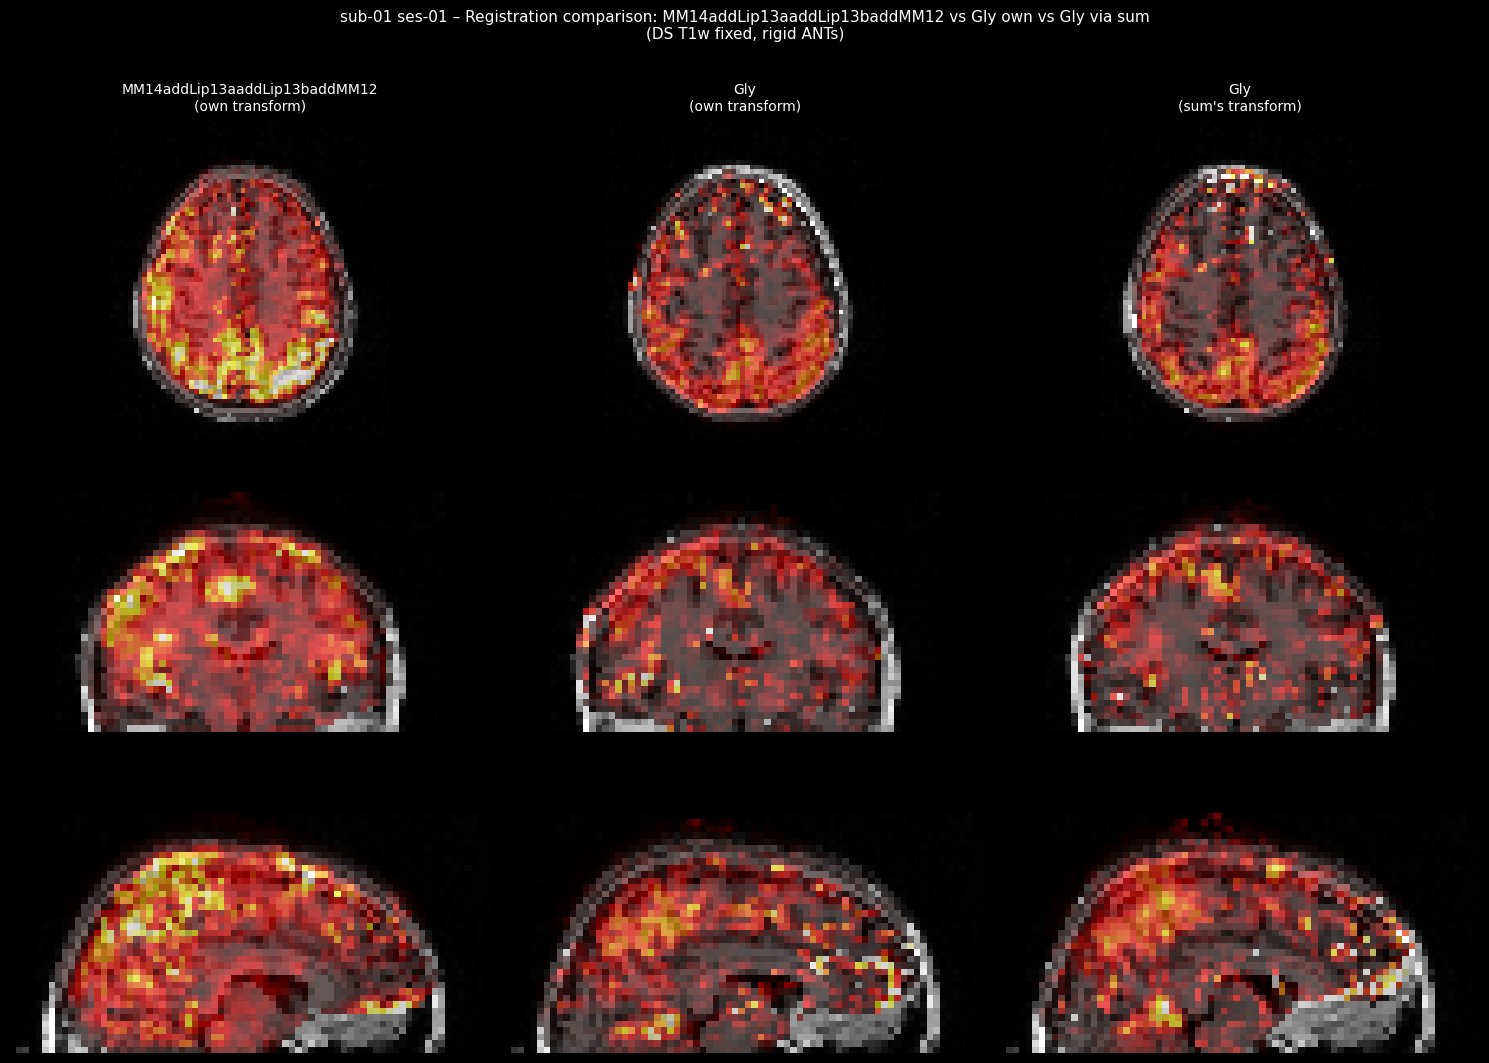


  Strategy                               Mean in brain   CC with T1w
  ------------------------------------------------------------------
  MM14addLip13aaddLip13baddMM12 — own transform          0.2240        0.0303
  Gly — own transform                           0.1322       -0.0036
  Gly — sum's transform                         0.1325       -0.0051


In [17]:
 
print(f"Best-coverage metabolite : {best_cov_label}  ({coverage_records[0]['n_voxels']} voxels)")
print(f"Best-SNR (Gly)           : {best_mrsi_label}  ({snr_records[0]['n_voxels']} voxels)")

plot_coverage_registration_comparison(
    t1w_ds_img,
    mrsi_cov_reg_img,
    mrsi_reg_ds_img,
    mrsi_gly_via_sum_img,
    subj=SUBJ,
    ses=SES,
    cov_label=best_cov_label,
    gly_label=best_mrsi_label,
)


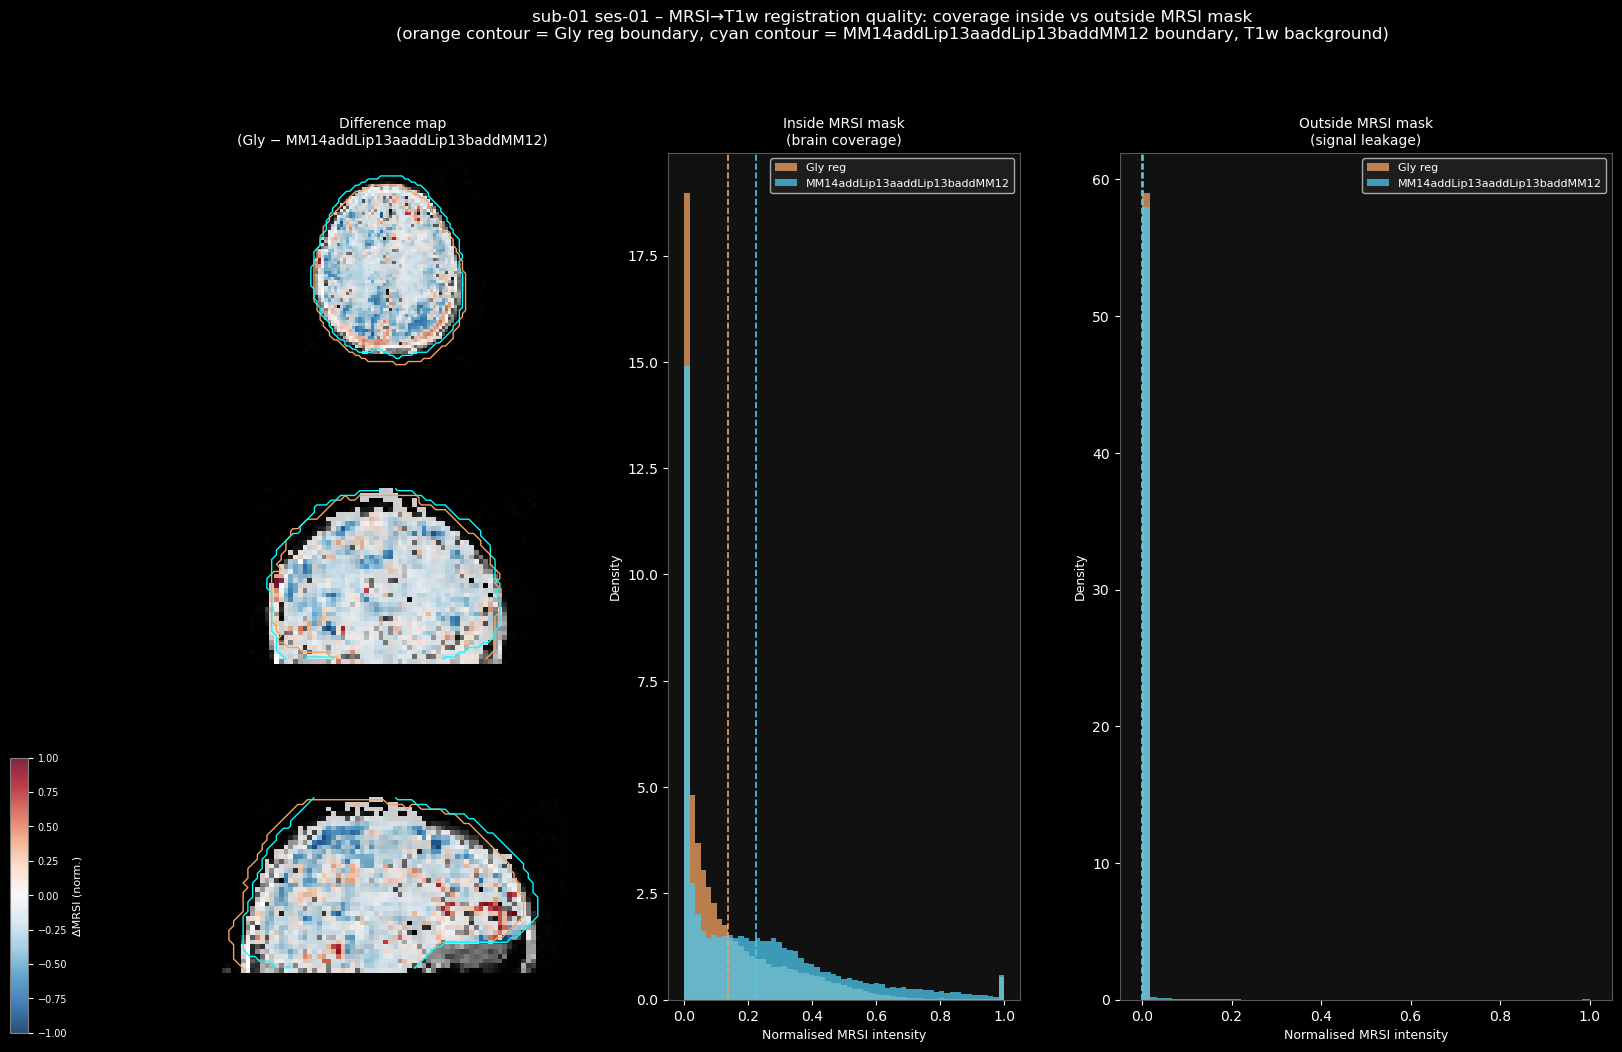

Metric                               Gly reg  MM14addLip13aaddLip13baddMM12         Δ (a−b)
───────────────────────────────────────────────────────────────────────────────────────────
Mean MRSI in-mask                     0.1361          0.2239         -0.0878
Mean MRSI out-of-mask                 0.0000          0.0027         -0.0027
In/Out SNR ratio              136108479.7430         84.2876  +136108395.4553
% active voxels in-mask              53.7456         66.8004        -13.0548
% active voxels out                   0.0000          1.1517         -1.1517


{'best_snr': {'mean_in': 0.1361084797429643,
  'mean_out': 0.0,
  'snr_ratio': 136108479.7429643,
  'pct_active_in': 53.745622413244185,
  'pct_active_out': 0.0},
 'sum': {'mean_in': 0.22394056547943356,
  'mean_out': 0.0026568601610846274,
  'snr_ratio': 84.28764316311239,
  'pct_active_in': 66.80038204393504,
  'pct_active_out': 1.1517111136545723}}

In [18]:

compare_registration_coverage(
    t1w_ds_img,
    water_mask,
    best_mrsi_img,
    mrsi_reg_ds_img,
    mrsi_cov_reg_img,
    reg1_transforms,
    reg6_transforms,
    subj=SUBJ,
    ses=SES,
    bestsnr_label=best_mrsi_label,
    sum_label=best_cov_label,
)


## 15 – Inverse registration: T1w to MRSI space

Register the downsampled T1w (moving) to each MRSI map (fixed).




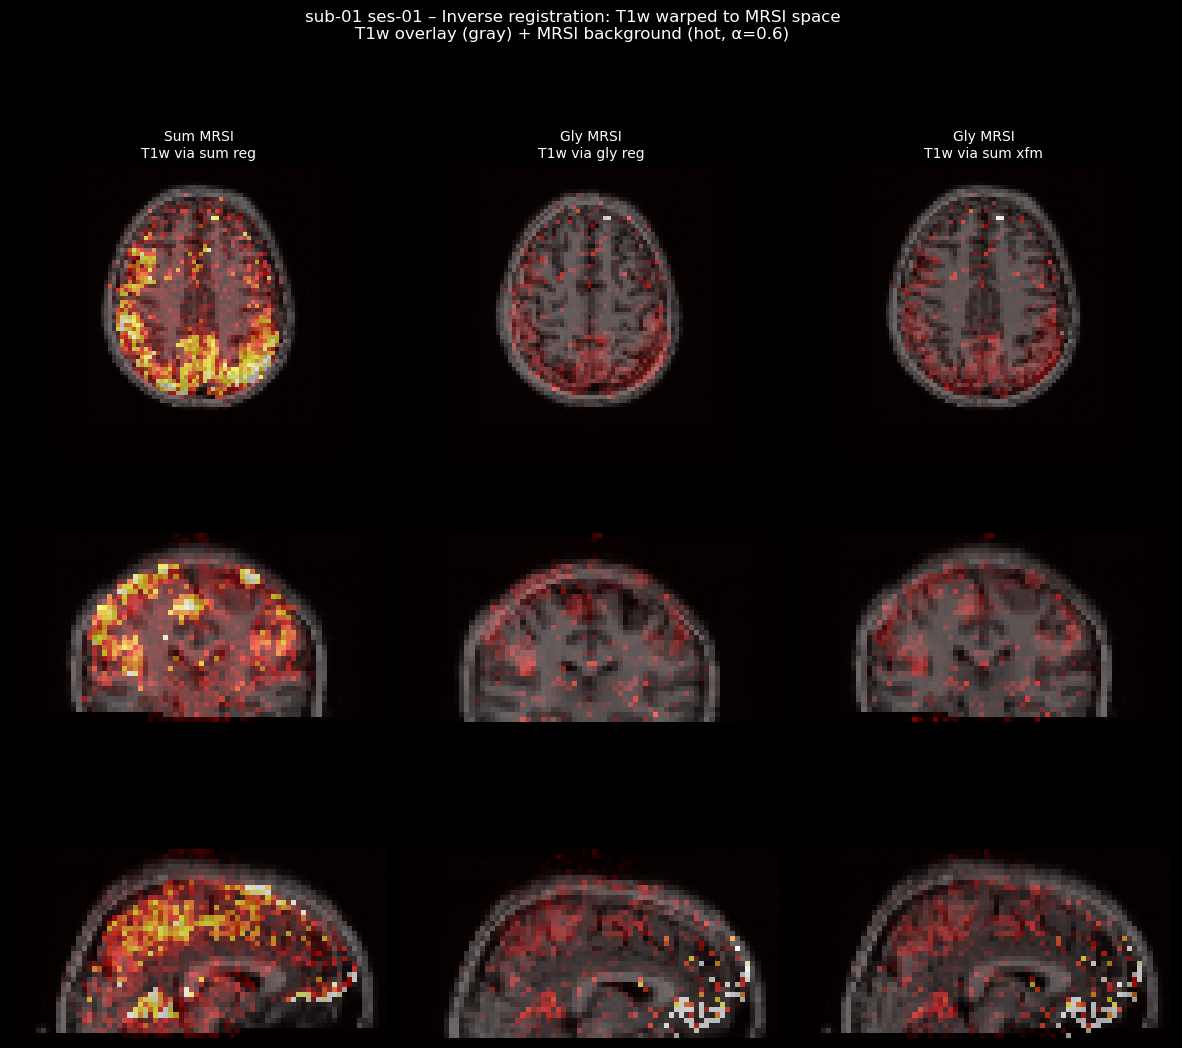

In [19]:

plot_inverse_registration_panels(
    mrsi_sum_img=sum_img,
    mrsi_gly_img=best_mrsi_img,
    t1w_via_sum_img=t1w_in_sum_img,
    t1w_via_gly_img=t1w_in_gly_img,
    t1w_via_sum_in_gly_img=t1w_via_sum_in_gly_img,
    subj=SUBJ,
    ses=SES,
    sum_label="Sum",
    gly_label=best_mrsi_label,
)


## 16 – Weighted inverse registration: water signal as mask

Supply the water signal image  as `mask` (fixed-image mask) in ANTs.

Three comparisons on the MRSI background:
- Left  T1w via no weighting mask inverse registration (Reg 8).
- Right  T1w via water weighted inverse registration (Reg 10).

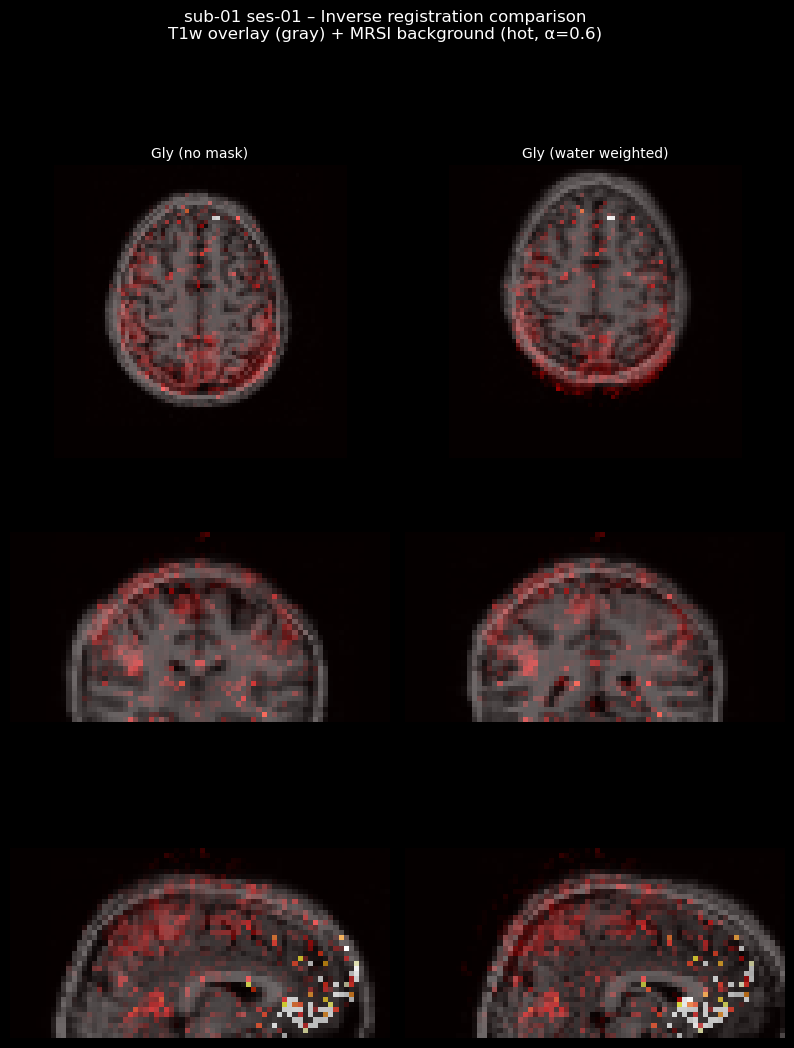

In [20]:

compare_inverse_registration_pair(
    best_mrsi_img,
    t1w_in_gly_img,
    t1w_in_gly_w_img,
    subj=SUBJ,
    ses=SES,
    label_left=f"{best_mrsi_label} (no mask)",
    label_right=f"{best_mrsi_label} (water weighted)",
)

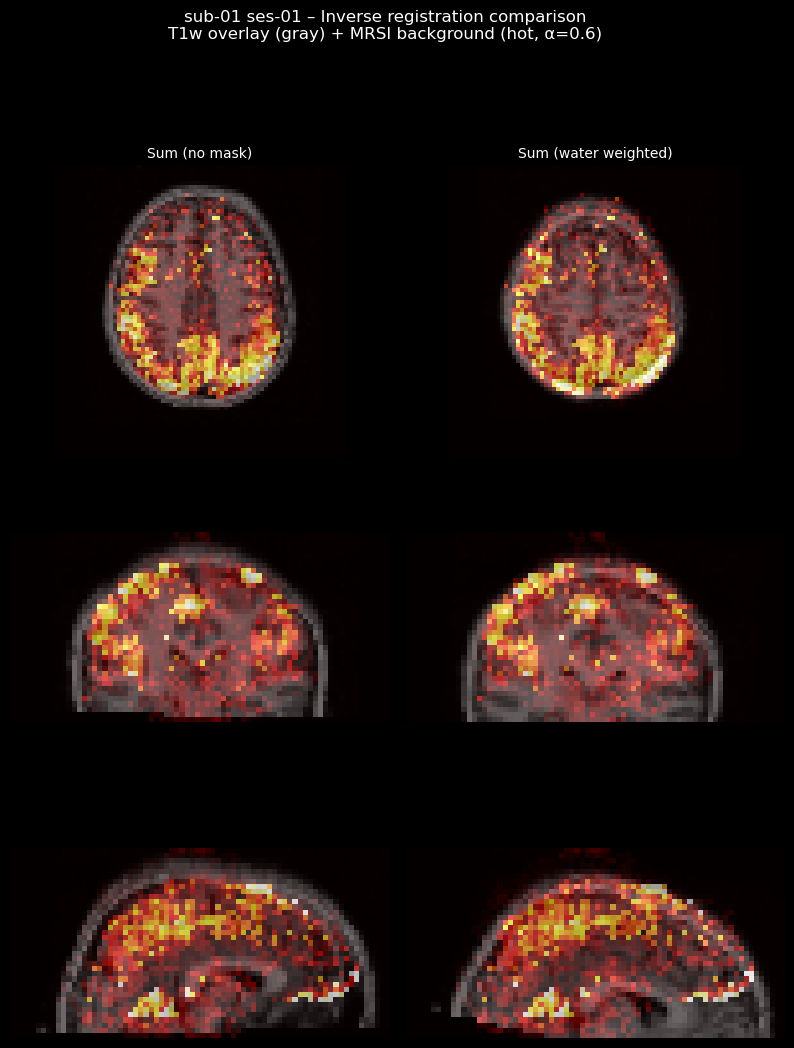

In [21]:
compare_inverse_registration_pair(
    sum_img,
    t1w_in_sum_img,
    t1w_in_sum_w_img,
    subj=SUBJ,
    ses=SES,
    label_left="Sum (no mask)",
    label_right="Sum (water weighted)",
)

## 17 – Water map alignment: naive vs Reg-11 reused vs Reg-18 direct

Three-way comparison on the **water signal map** background (all T1w images in water-signal coordinate space):

| Column | Method | Description |
|--------|--------|-------------|
| Left | Naive | Full-res T1w directly resampled to water grid — no registration |
| Middle | Reg-11 reused | Reg-11 sum water-weighted transform (`inv_sum_w_transforms`) applied to T1w DS, resampled to water space — no re-optimisation |
| Right | Reg-18 | T1w DS directly registered to water signal map (ANTs CLI rigid + water mask) |


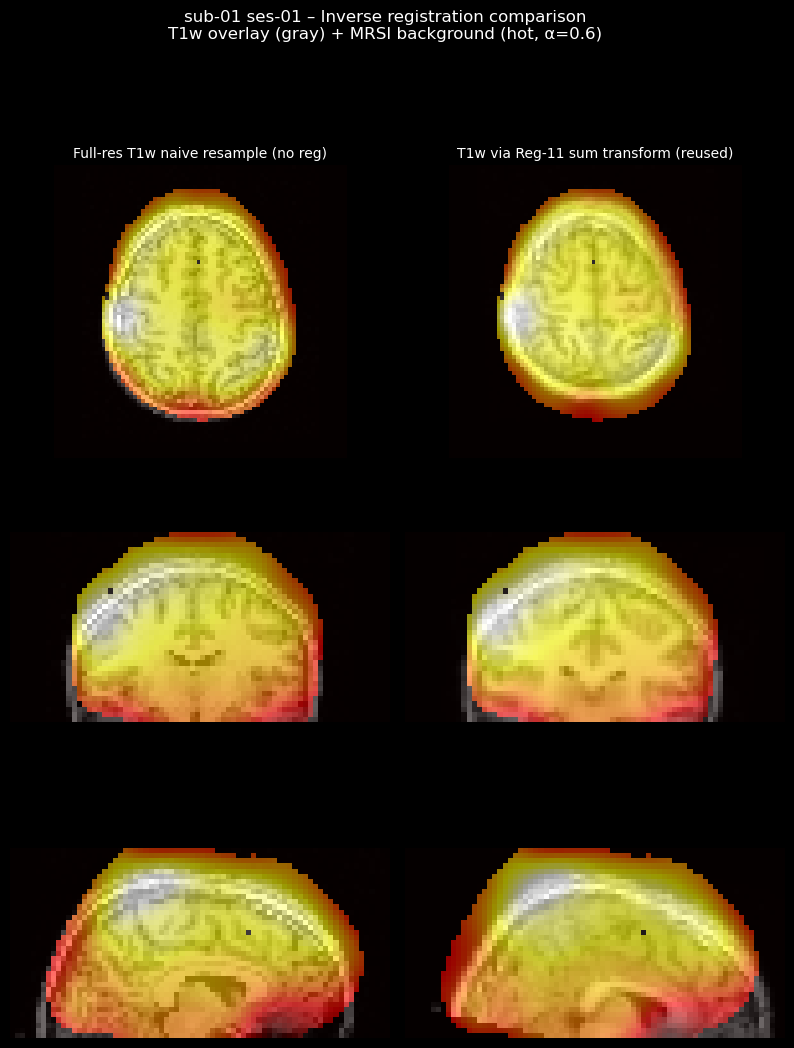

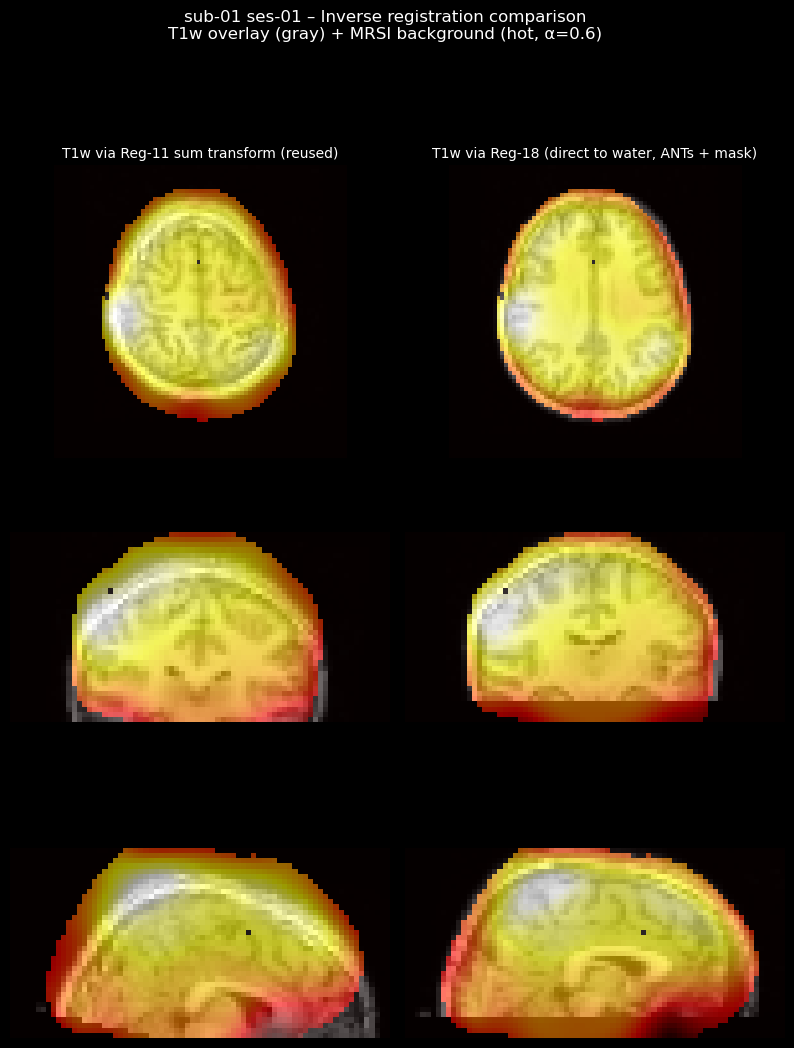

In [22]:

# Left vs middle: naive resample vs Reg-11 sum transform reused
compare_inverse_registration_pair(
    water_img,
    t1w_ds_img,
    t1w_in_water_via17_img,
    subj=SUBJ,
    ses=SES,
    label_left="Full-res T1w naive resample (no reg)",
    label_right="T1w via Reg-11 sum transform (reused)",
)

# Middle vs right: Reg-11 reused vs Reg-18 direct
compare_inverse_registration_pair(
    water_img,
    t1w_in_water_via17_img,
    t1w_in_water_img,
    subj=SUBJ,
    ses=SES,
    label_left="T1w via Reg-11 sum transform (reused)",
    label_right="T1w via Reg-18 (direct to water, ANTs + mask)",
)


## 18 – Skull-stripped T1w registered to MRSI space

The downsampled T1w is first skull-stripped with FSL BET (`-f 0.3`).


  [reg17] already exists: /Users/user/FCBG_project_Connectome_registraction/Code/FCBG_project_Connectome_registraction/data/output/sub-01_ses-01_desc-GlyInT1wNoSkullStrip_T1w.nii.gz
  [reg17] already exists: /Users/user/FCBG_project_Connectome_registraction/Code/FCBG_project_Connectome_registraction/data/output/sub-01_ses-01_desc-GlyInT1wSkullStripped_T1w.nii.gz


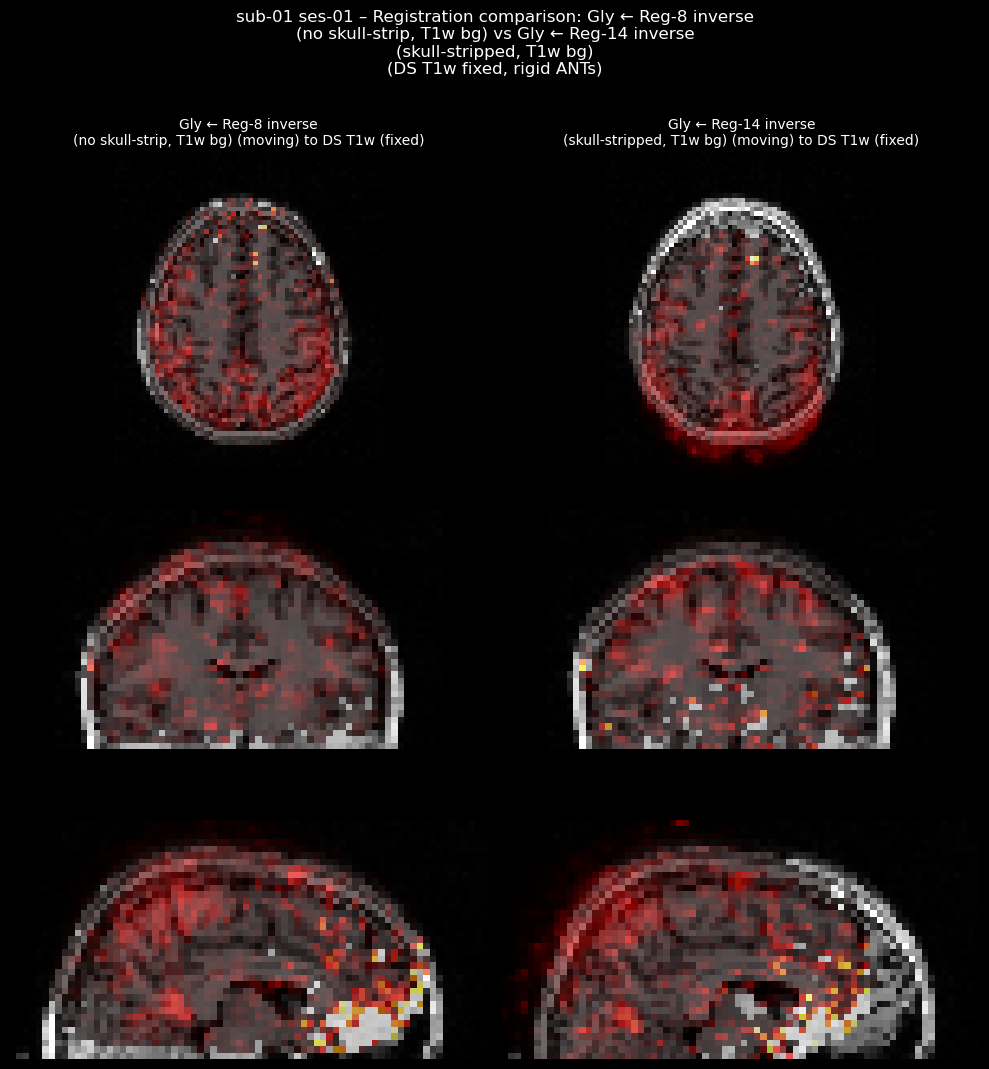

In [23]:

# Gly: no skull-strip vs skull-stripped — MRSI in T1w space (inverse transform)
# Background = DS T1w WITH full skull (t1w_ds_img) for both panels
_gly_noss_t1w_path = os.path.join(OUTPUT_DIR, f"{SUBJ}_{SES}_desc-GlyInT1wNoSkullStrip_T1w.nii.gz")
_gly_ss_t1w_path   = os.path.join(OUTPUT_DIR, f"{SUBJ}_{SES}_desc-GlyInT1wSkullStripped_T1w.nii.gz")

# Left: inverse of Reg-8  (full T1w → Gly MRSI space)  →  Gly map in T1w space
gly_in_t1w_noss = apply_transform_to_metabolite(
    mrsi_path=BEST_MRSI_PATH,
    transform_path=inv_gly_transforms[0],
    t1w_ref_path=T1W_DS_PATH,
    out_path=_gly_noss_t1w_path,
    overwrite=False,
)
# Right: inverse of Reg-14 (skull-stripped T1w → Gly MRSI space)  →  Gly map in T1w space
gly_in_t1w_ss = apply_transform_to_metabolite(
    mrsi_path=BEST_MRSI_PATH,
    transform_path=brain_gly_transforms[0],
    t1w_ref_path=T1W_DS_PATH,
    out_path=_gly_ss_t1w_path,
    overwrite=False,
)
plot_registration_target_comparison(
    t1w_ds_img,
    gly_in_t1w_noss,
    gly_in_t1w_ss,
    subj=SUBJ,
    ses=SES,
    bestsnr_label=f"{best_mrsi_label} ← Reg-8 inverse\n(no skull-strip, T1w bg)",
    sum_label=f"{best_mrsi_label} ← Reg-14 inverse\n(skull-stripped, T1w bg)",
)


  [reg17] already exists: /Users/user/FCBG_project_Connectome_registraction/Code/FCBG_project_Connectome_registraction/data/output/sub-01_ses-01_desc-SumInT1wNoSkullStrip_T1w.nii.gz
  [reg17] already exists: /Users/user/FCBG_project_Connectome_registraction/Code/FCBG_project_Connectome_registraction/data/output/sub-01_ses-01_desc-SumInT1wSkullStripped_T1w.nii.gz


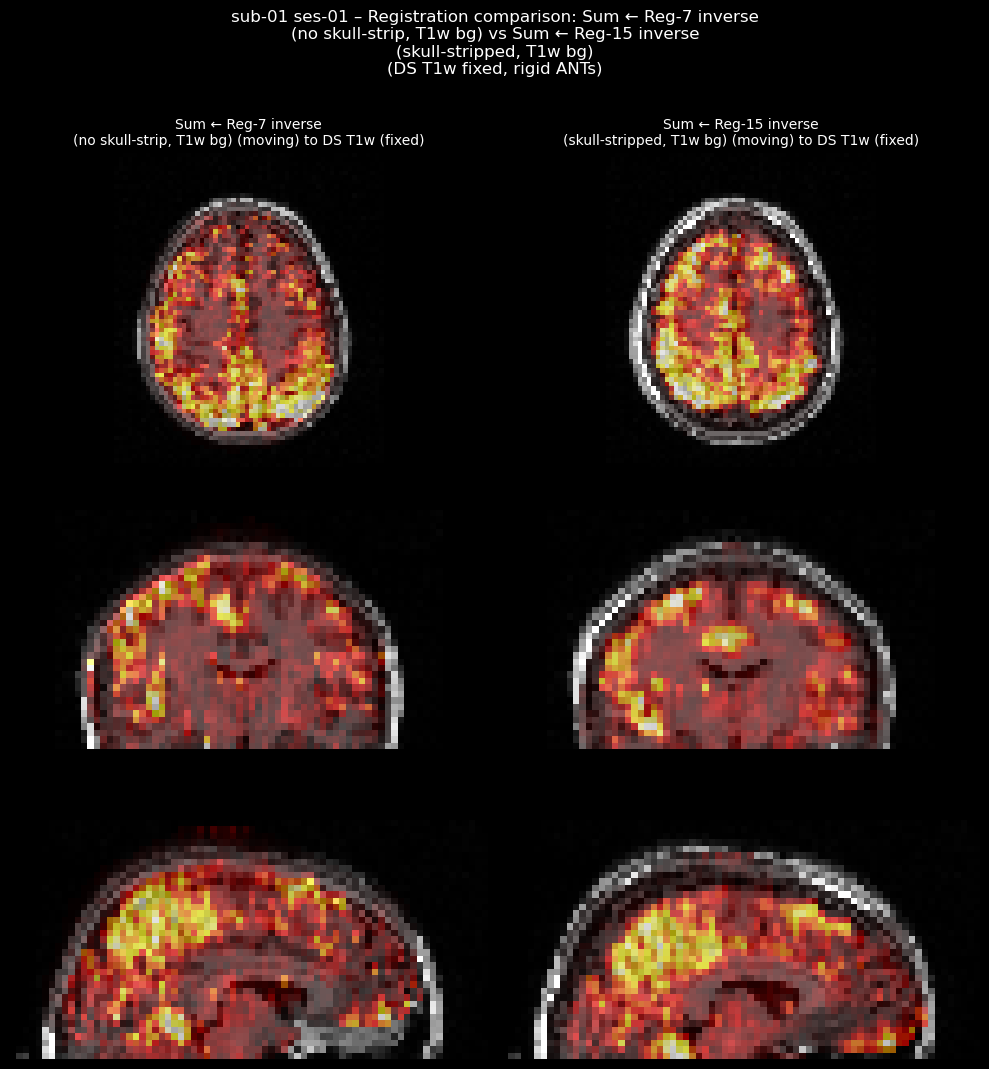

In [24]:

# Sum: no skull-strip vs skull-stripped — MRSI in T1w space (inverse transform)
# Background = DS T1w WITH full skull (t1w_ds_img) for both panels
_sum_noss_t1w_path = os.path.join(OUTPUT_DIR, f"{SUBJ}_{SES}_desc-SumInT1wNoSkullStrip_T1w.nii.gz")
_sum_ss_t1w_path   = os.path.join(OUTPUT_DIR, f"{SUBJ}_{SES}_desc-SumInT1wSkullStripped_T1w.nii.gz")

# Left: inverse of Reg-7  (full T1w → Sum MRSI space)  →  Sum map in T1w space
sum_in_t1w_noss = apply_transform_to_metabolite(
    mrsi_path=SUM_PATH,
    transform_path=inv_sum_transforms[0],
    t1w_ref_path=T1W_DS_PATH,
    out_path=_sum_noss_t1w_path,
    overwrite=False,
)
# Right: inverse of Reg-15 (skull-stripped T1w → Sum MRSI space)  →  Sum map in T1w space
sum_in_t1w_ss = apply_transform_to_metabolite(
    mrsi_path=SUM_PATH,
    transform_path=brain_sum_transforms[0],
    t1w_ref_path=T1W_DS_PATH,
    out_path=_sum_ss_t1w_path,
    overwrite=False,
)
plot_registration_target_comparison(
    t1w_ds_img,
    sum_in_t1w_noss,
    sum_in_t1w_ss,
    subj=SUBJ,
    ses=SES,
    bestsnr_label="Sum ← Reg-7 inverse\n(no skull-strip, T1w bg)",
    sum_label="Sum ← Reg-15 inverse\n(skull-stripped, T1w bg)",
)


## 19 – Total pipeline: reoriented MRSI sum + skull-stripped T1w + water-weighted registration

End-to-end best-practice pipeline combining all preprocessing steps:

1. Reorient all MRSI concentration maps to RAS canonical orientation (`nibabel.as_closest_canonical`).
2. Sum the reoriented maps → `AllMetabSumRAS` (maximises SNR, consistent voxel ordering).
3. Skull-strip the downsampled T1w with FSL BET (`-f 0.3`) to removes non-brain tissue.
4. Register skull-stripped T1w → reoriented sum using `antsRegistration` with the reoriented water signal as a fixed-image weight (`--masks`).

The visualisation below compares:
- Left skull-stripped T1w registered to the *original* (non-reoriented) sum (Reg 15).
- Right  skull-stripped T1w registered to the *reoriented* sum (Reg 17, total pipeline).

## 19b – Reg-17 total pipeline: effect of moving-mask choice (BET vs FreeSurfer)

The Reg-17 pipeline registers the skull-stripped DS T1w to the reoriented MRSI sum using a water-signal fixed mask. The moving mask constrains which voxels of the T1w drive the optimisation. 2 variants are compared:

| Column | Moving mask |
|--------|-------------|
| **BET** | FSL BET binary brain mask (DS)|
| **FreeSurfer** | UNIDEND atlas brain mask (DS)|



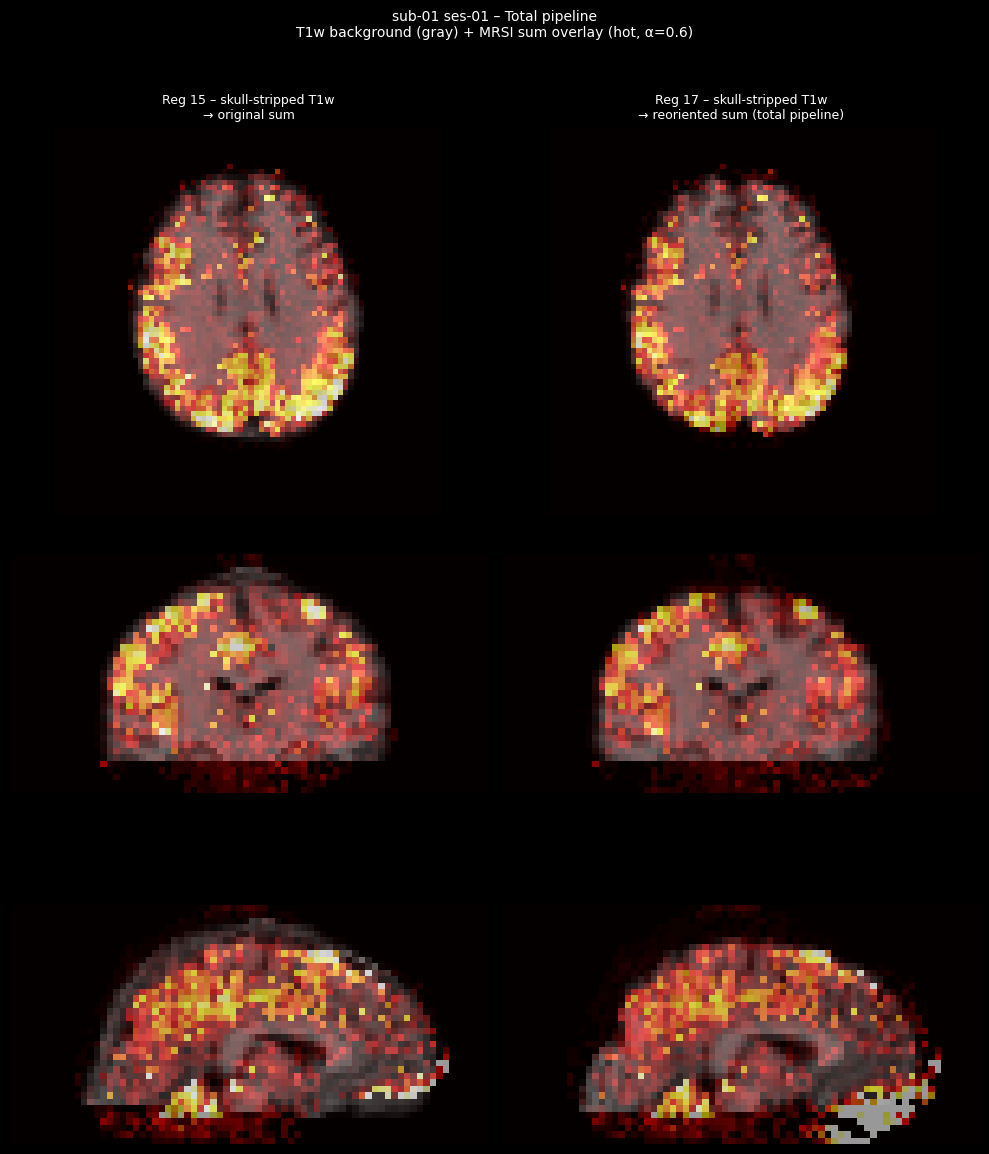

In [25]:

plot_total_pipeline_comparison(
    sum_orig_img=sum_img,
    t1w_in_sum_orig_img=t1w_brain_in_sum_ras_img_freesurfer_mask,
    sum_ras_img=sum_ras_img,
    t1w_in_sum_ras_img=t1w_brain_in_sum_ras_img_bet_mask,
    subj=SUBJ,
    ses=SES,
)

  [reg17] already exists: /Users/user/FCBG_project_Connectome_registraction/Code/FCBG_project_Connectome_registraction/data/output/sub-01_ses-01_desc-SumInT1wReg17BET_T1w.nii.gz
  [reg17] already exists: /Users/user/FCBG_project_Connectome_registraction/Code/FCBG_project_Connectome_registraction/data/output/sub-01_ses-01_desc-SumInT1wReg17FS_T1w.nii.gz


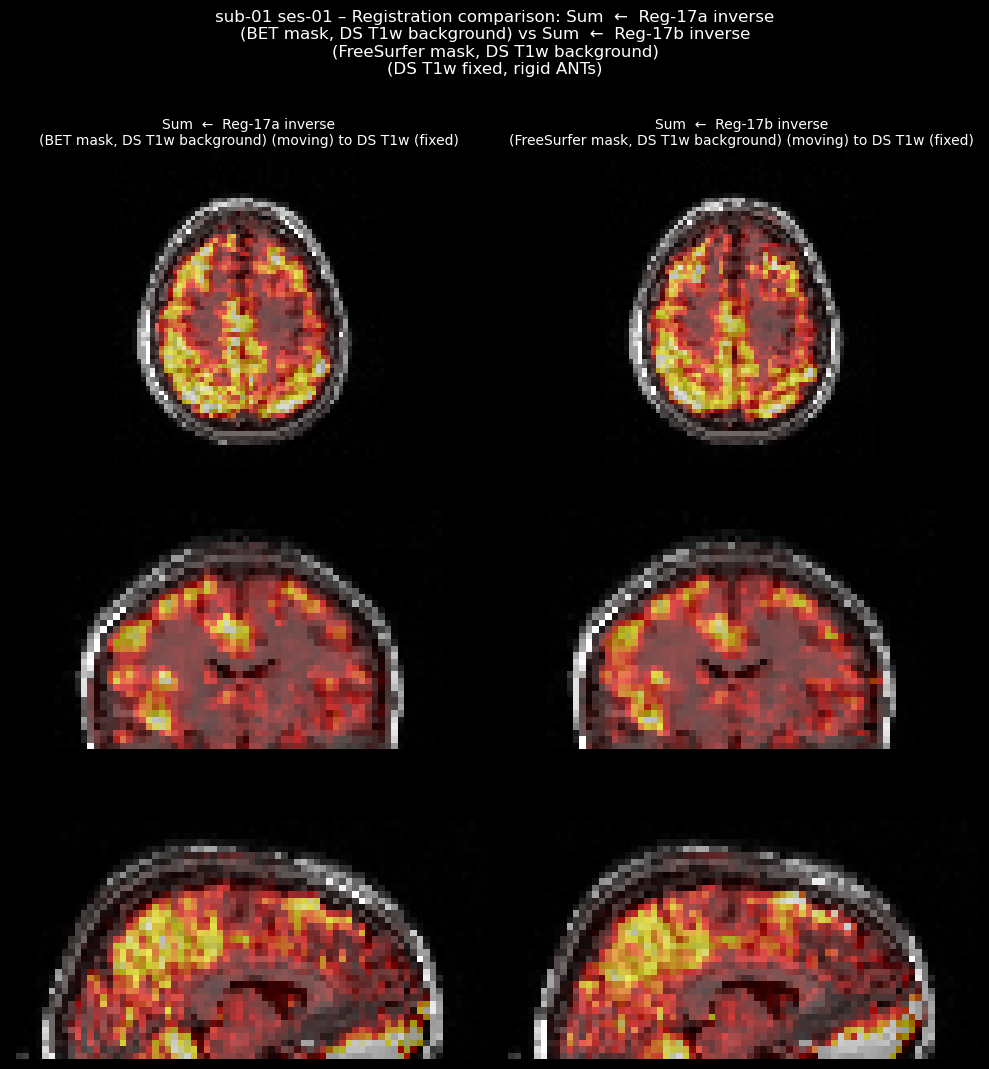

In [26]:

# 19b inverse: MRSI sum in T1w space – BET mask (Reg-17a) vs FreeSurfer mask (Reg-17b)
# Background: DS T1w with skull (t1w_ds_img)
_sum_bet_t1w_path = os.path.join(OUTPUT_DIR, f"{SUBJ}_{SES}_desc-SumInT1wReg17BET_T1w.nii.gz")
_sum_fs_t1w_path  = os.path.join(OUTPUT_DIR, f"{SUBJ}_{SES}_desc-SumInT1wReg17FS_T1w.nii.gz")

sum_in_t1w_bet = apply_transform_to_metabolite(
    mrsi_path=SUM_RAS_PATH,
    transform_path=brain_sum_ras_transforms_bet_mask[0],
    t1w_ref_path=T1W_DS_PATH,
    out_path=_sum_bet_t1w_path,
    overwrite=False,
)
sum_in_t1w_fs = apply_transform_to_metabolite(
    mrsi_path=SUM_RAS_PATH,
    transform_path=brain_sum_ras_transforms_freesurfer_mask[0],
    t1w_ref_path=T1W_DS_PATH,
    out_path=_sum_fs_t1w_path,
    overwrite=False,
)
plot_registration_target_comparison(
    t1w_ds_img,
    sum_in_t1w_bet,
    sum_in_t1w_fs,
    subj=SUBJ,
    ses=SES,
    bestsnr_label="Sum  ←  Reg-17a inverse\n(BET mask, DS T1w background)",
    sum_label="Sum  ←  Reg-17b inverse\n(FreeSurfer mask, DS T1w background)",
)


## 20 – Final transform applied to all metabolites + registration quality metrics

The **Reg-17 transform** (skull-stripped DS T1w → reoriented MRSI sum, water-weighted) is
inverted and applied to every individual metabolite map, warping each one into T1w space
(`antsApplyTransforms [transform.mat, 1]`).

Three quality metrics are computed per metabolite in the **overlap region** (T1w brain > 0 ∩ MRSI signal > 0):

| Metric | Interpretation |
|--------|----------------|
| **Coverage** | Fraction of T1w brain voxels that contain MRSI signal after registration |
| **NCC** | Normalised cross correlation with T1w  higher = better spatial alignment |
| **NMI** | Normalised mutual information  higher = more shared information with T1w |

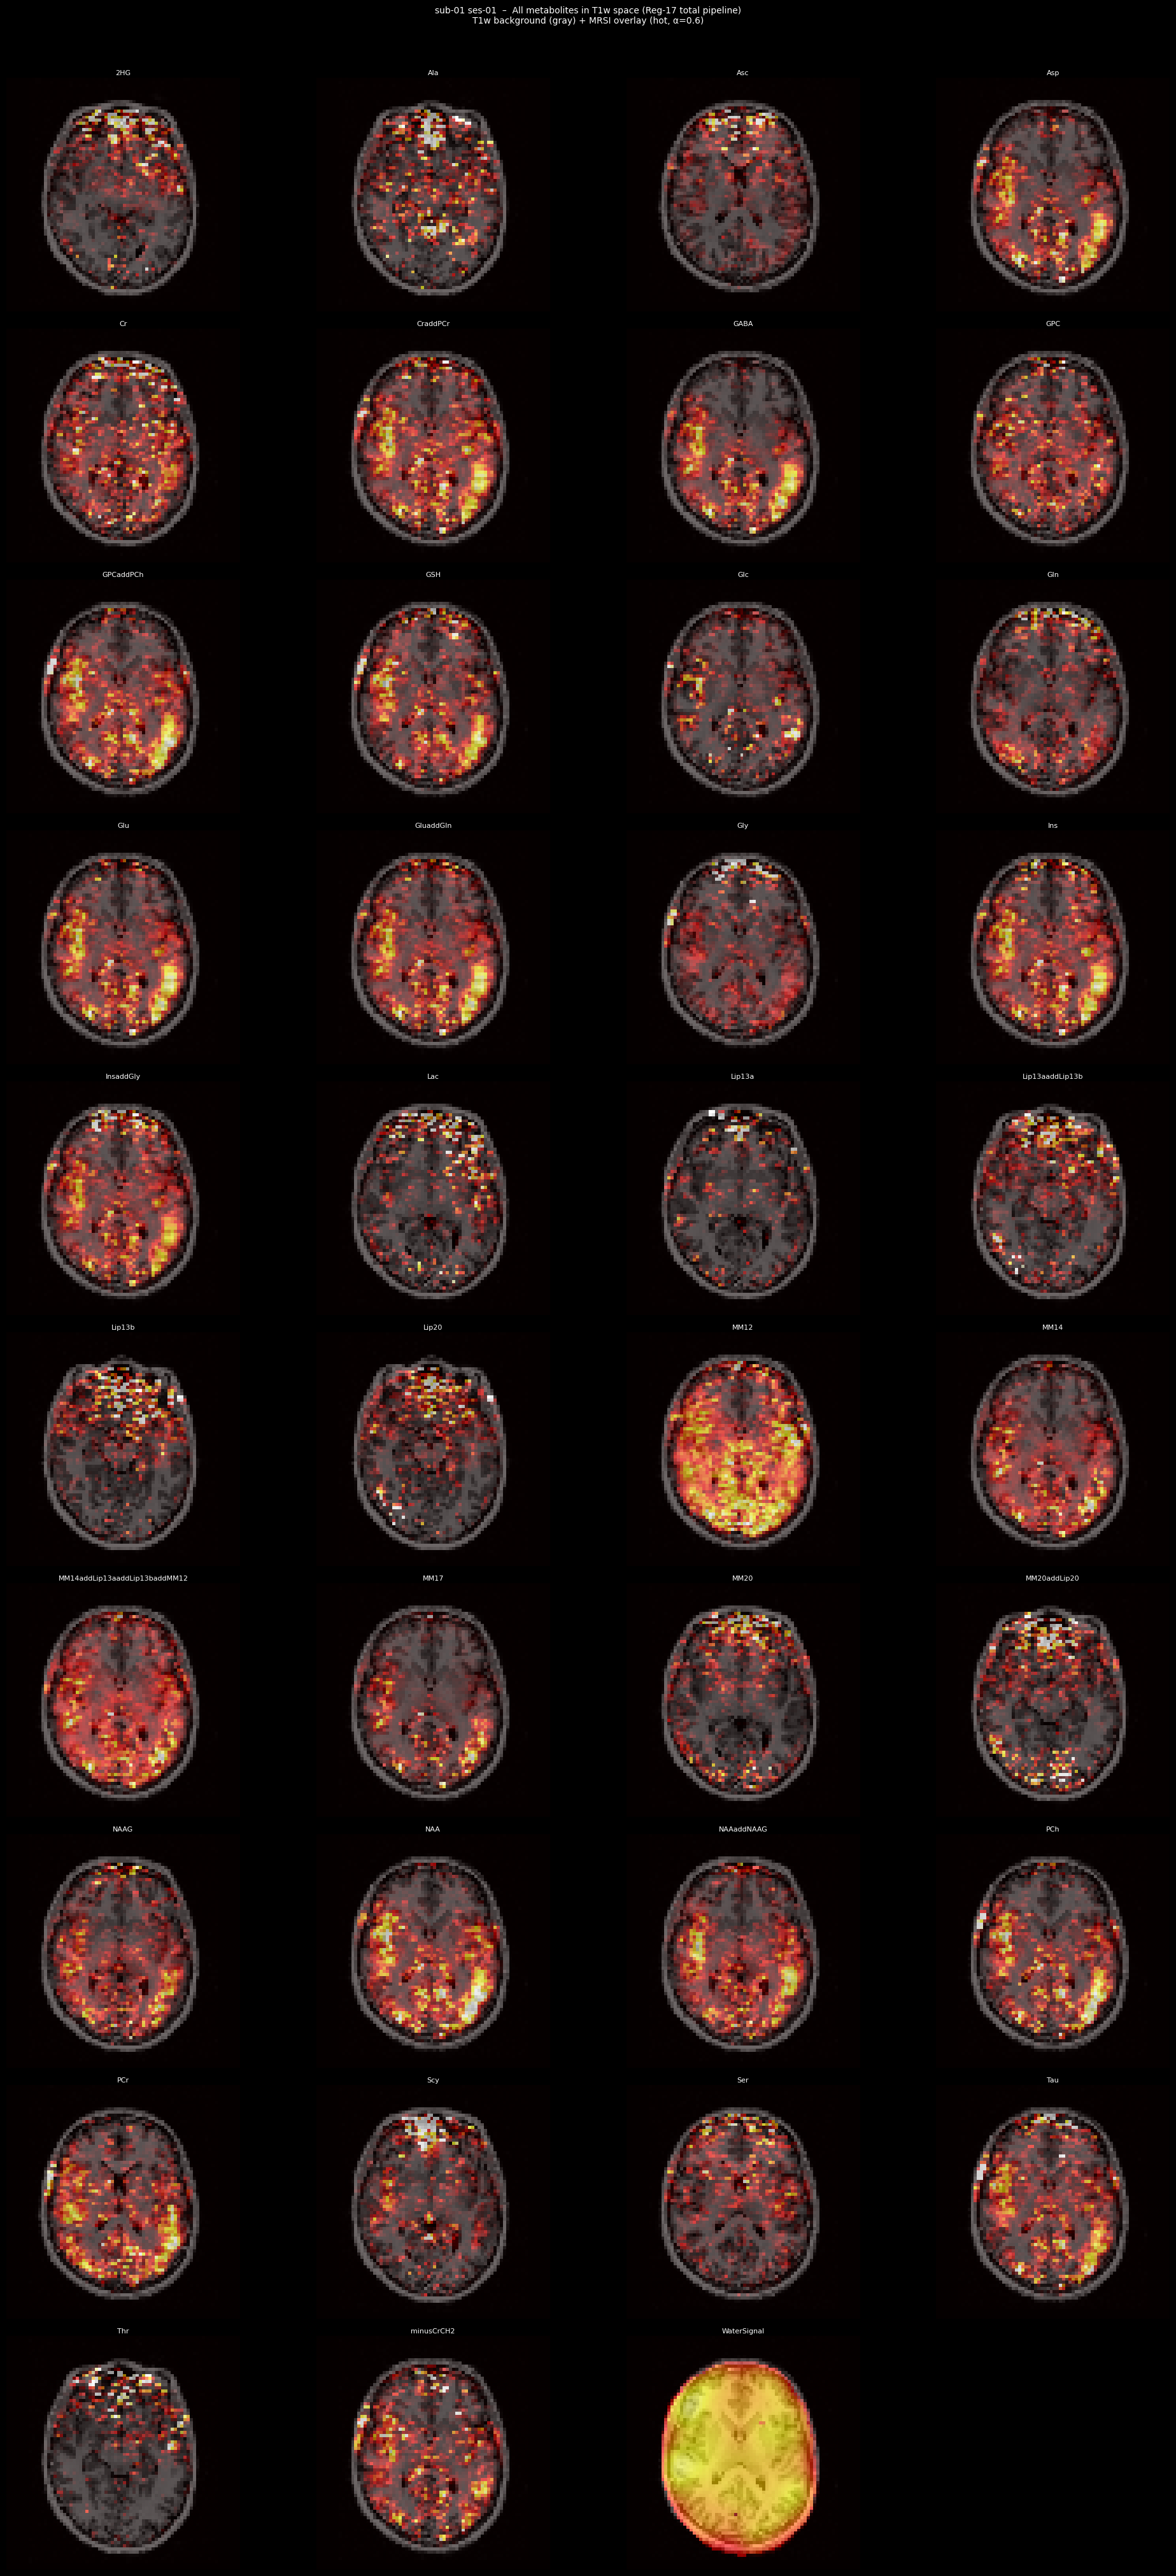

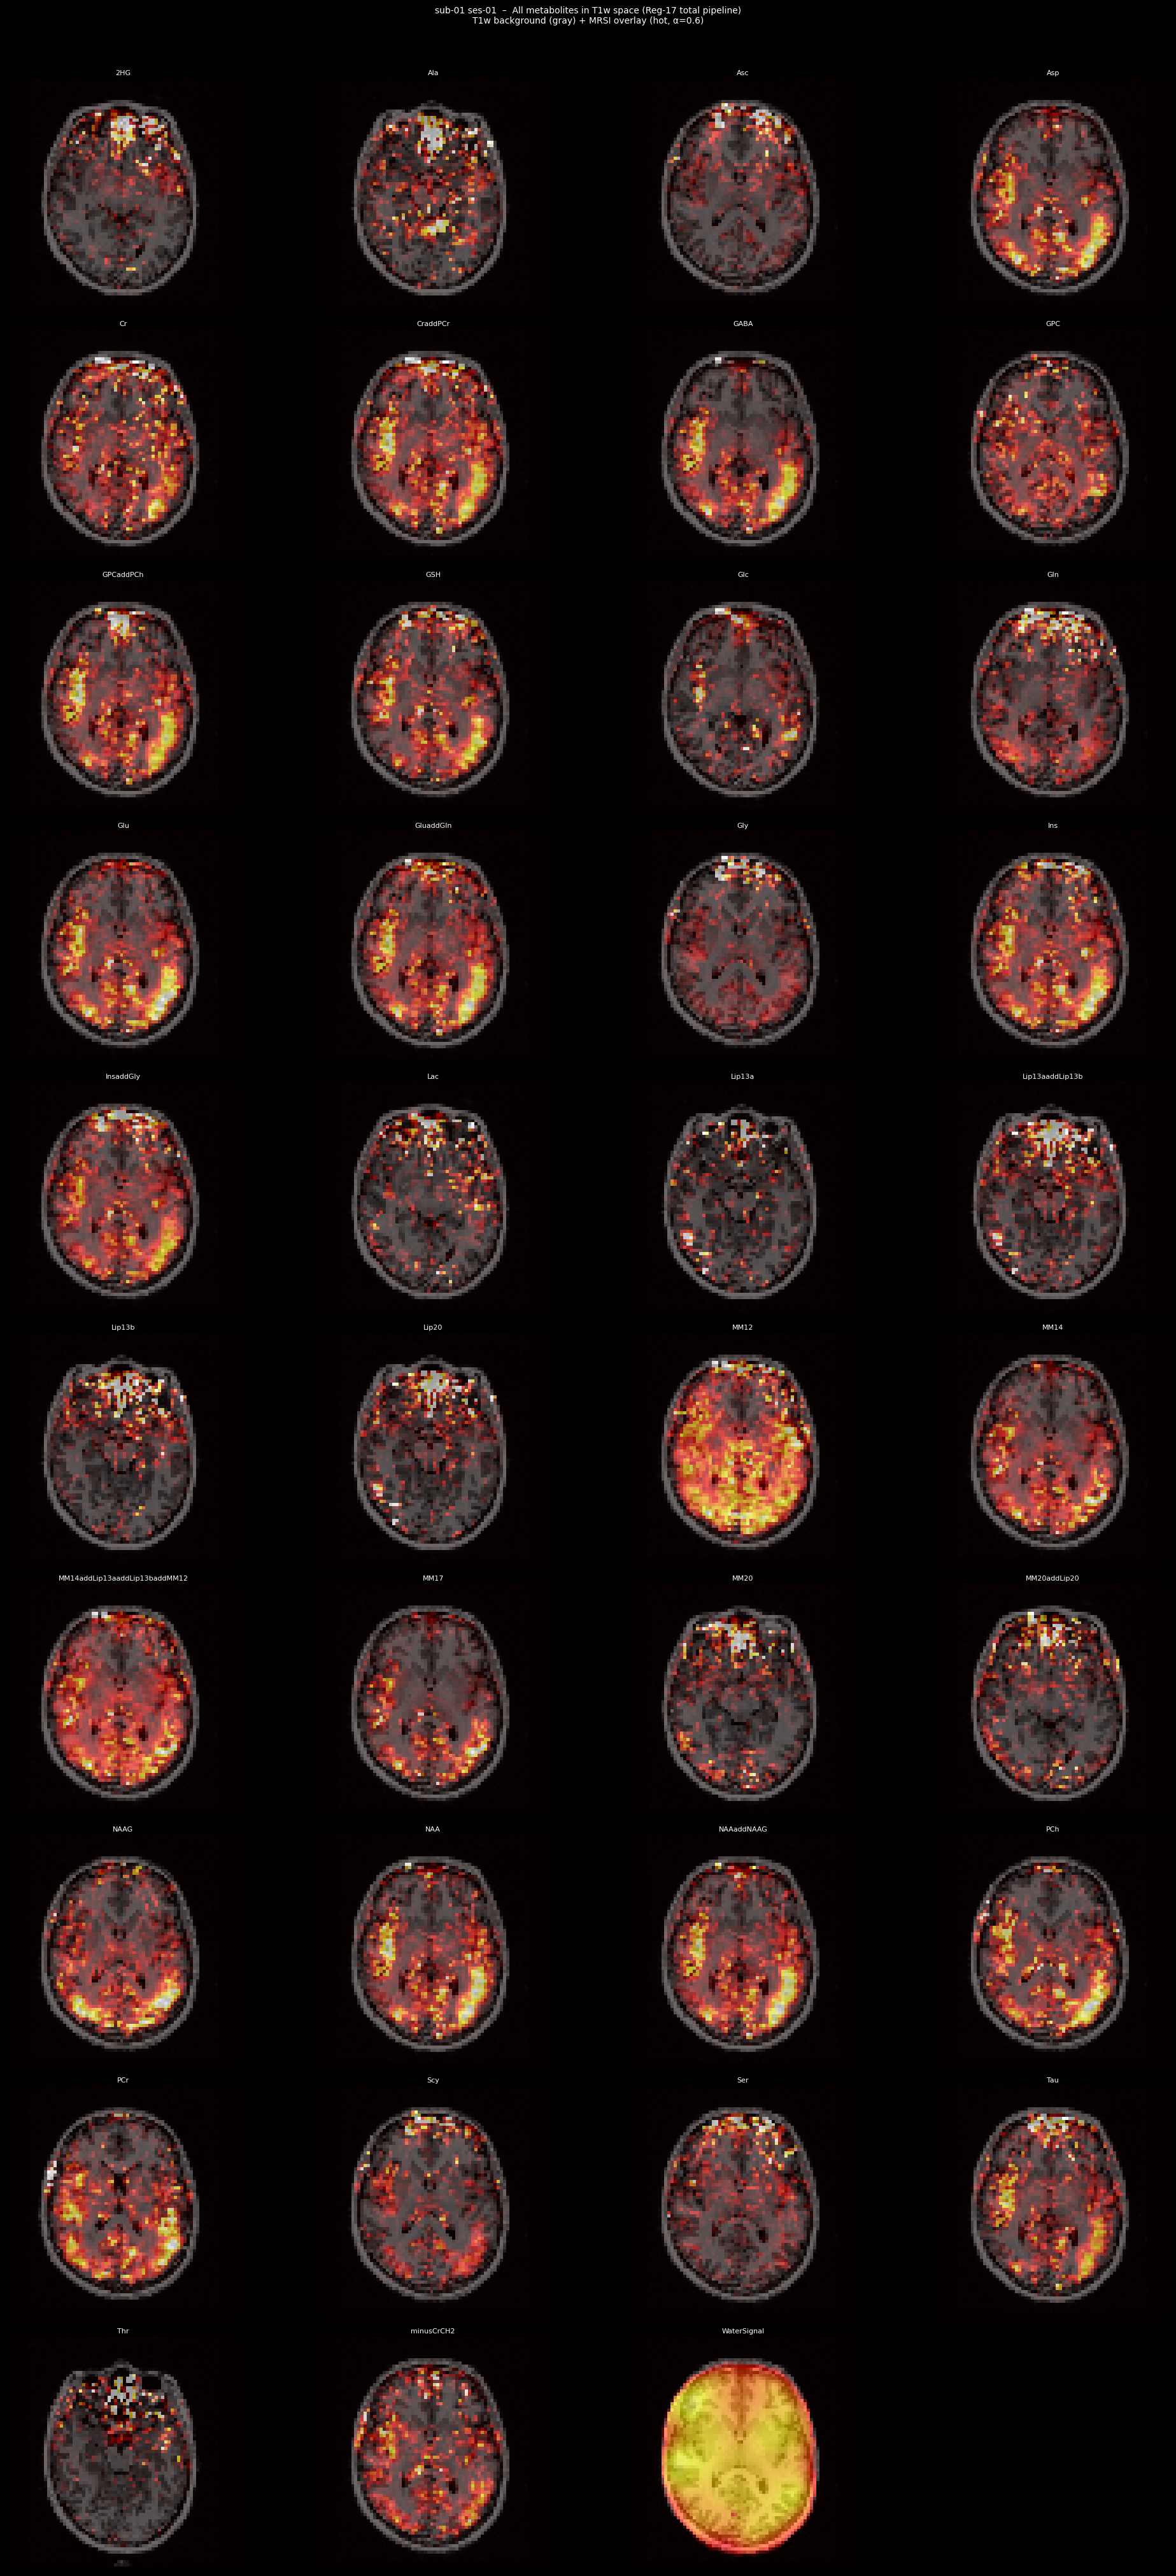

In [27]:
# Axial mosaic: every metabolite overlaid on the T1w background
plot_final_registration_mosaic(
    t1w_img=t1w_ds_img,
    reg_mrsi_imgs=final_reg_imgs_bet_mask,
    subj=SUBJ,
    ses=SES,
)

plot_final_registration_mosaic(
    t1w_img=t1w_ds_img,
    reg_mrsi_imgs=final_reg_imgs_freesurfer_mask,
    subj=SUBJ,
    ses=SES,
)

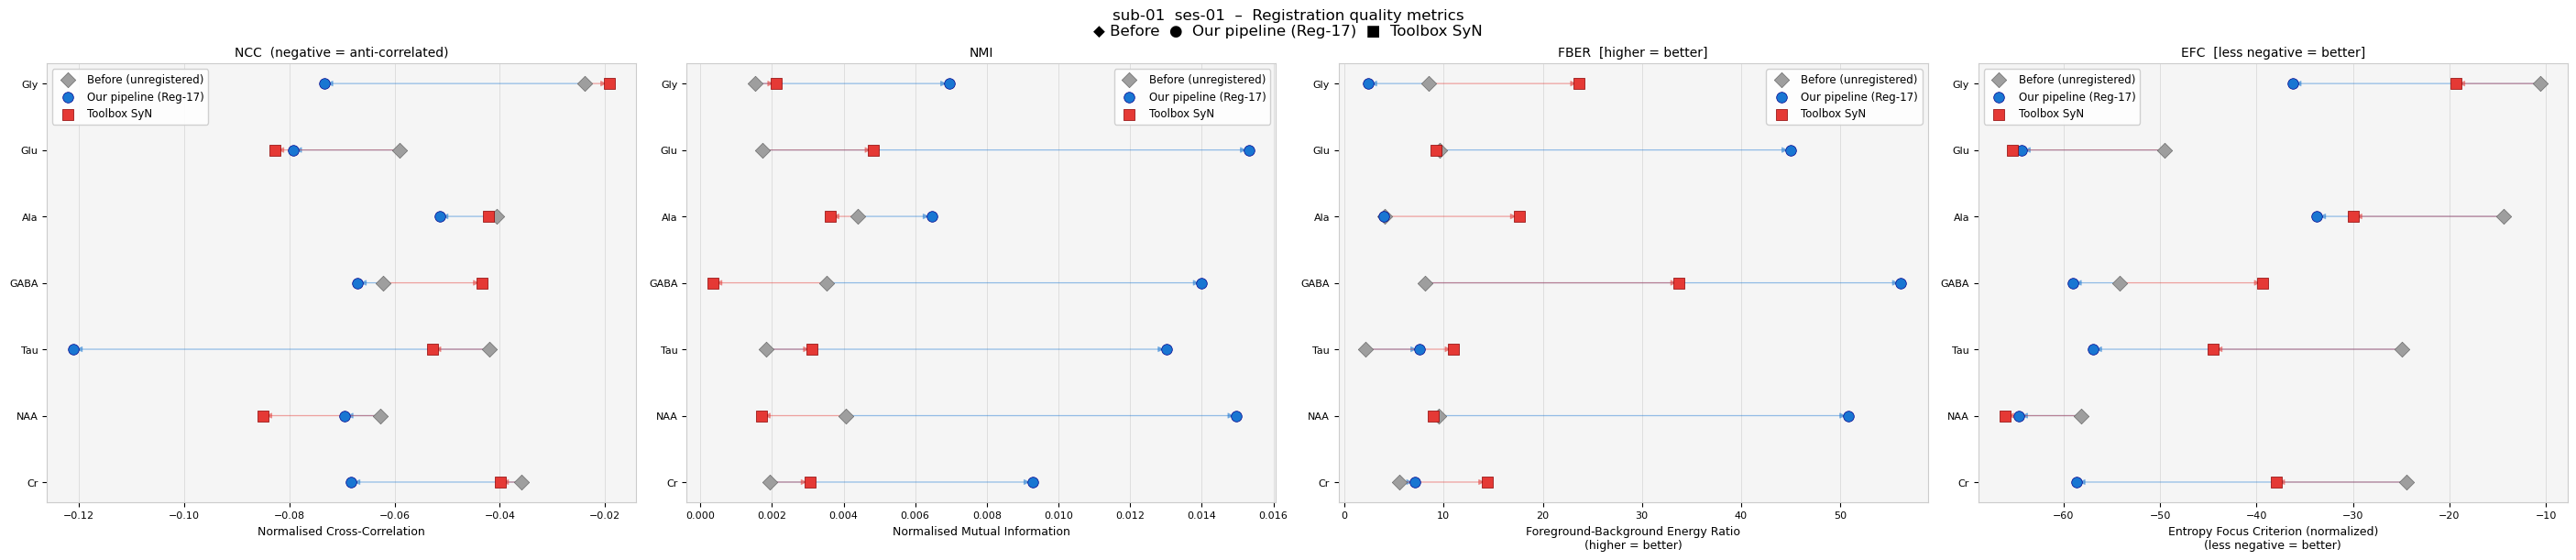


Label                                     NCC       NMI      FBER           EFC     NCC_B     NMI_B    FBER_B         EFC_B
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Cr                                    -0.0682    0.0093     7.118    -58.669748   -0.0400    0.0031    14.393    -37.984952
NAA                                   -0.0695    0.0150    50.822    -64.630652   -0.0849    0.0017     8.918    -66.066539
Tau                                   -0.1209    0.0130     7.541    -56.951459   -0.0528    0.0031    10.997    -44.464636
GABA                                  -0.0670    0.0140    56.138    -59.052546   -0.0434    0.0004    33.766    -39.350431
Ala                                   -0.0515    0.0065     3.957    -33.735816   -0.0422    0.0036    17.596    -29.969127
Glu                                   -0.0793    0.0153    44.983    -64.347416   -0.0827    0.0048     9.269    -65.355674
Gly    

In [36]:
_METABOLITES = ["Cr", "NAA", "Tau", "GABA", "Ala", "Glu", "Gly"]
plot_registration_metrics(metrics=metrics, subj=SUBJ, ses=SES, metrics_before=metrics_before,
                          metrics_b=metrics_toolbox, metabolites=_METABOLITES)

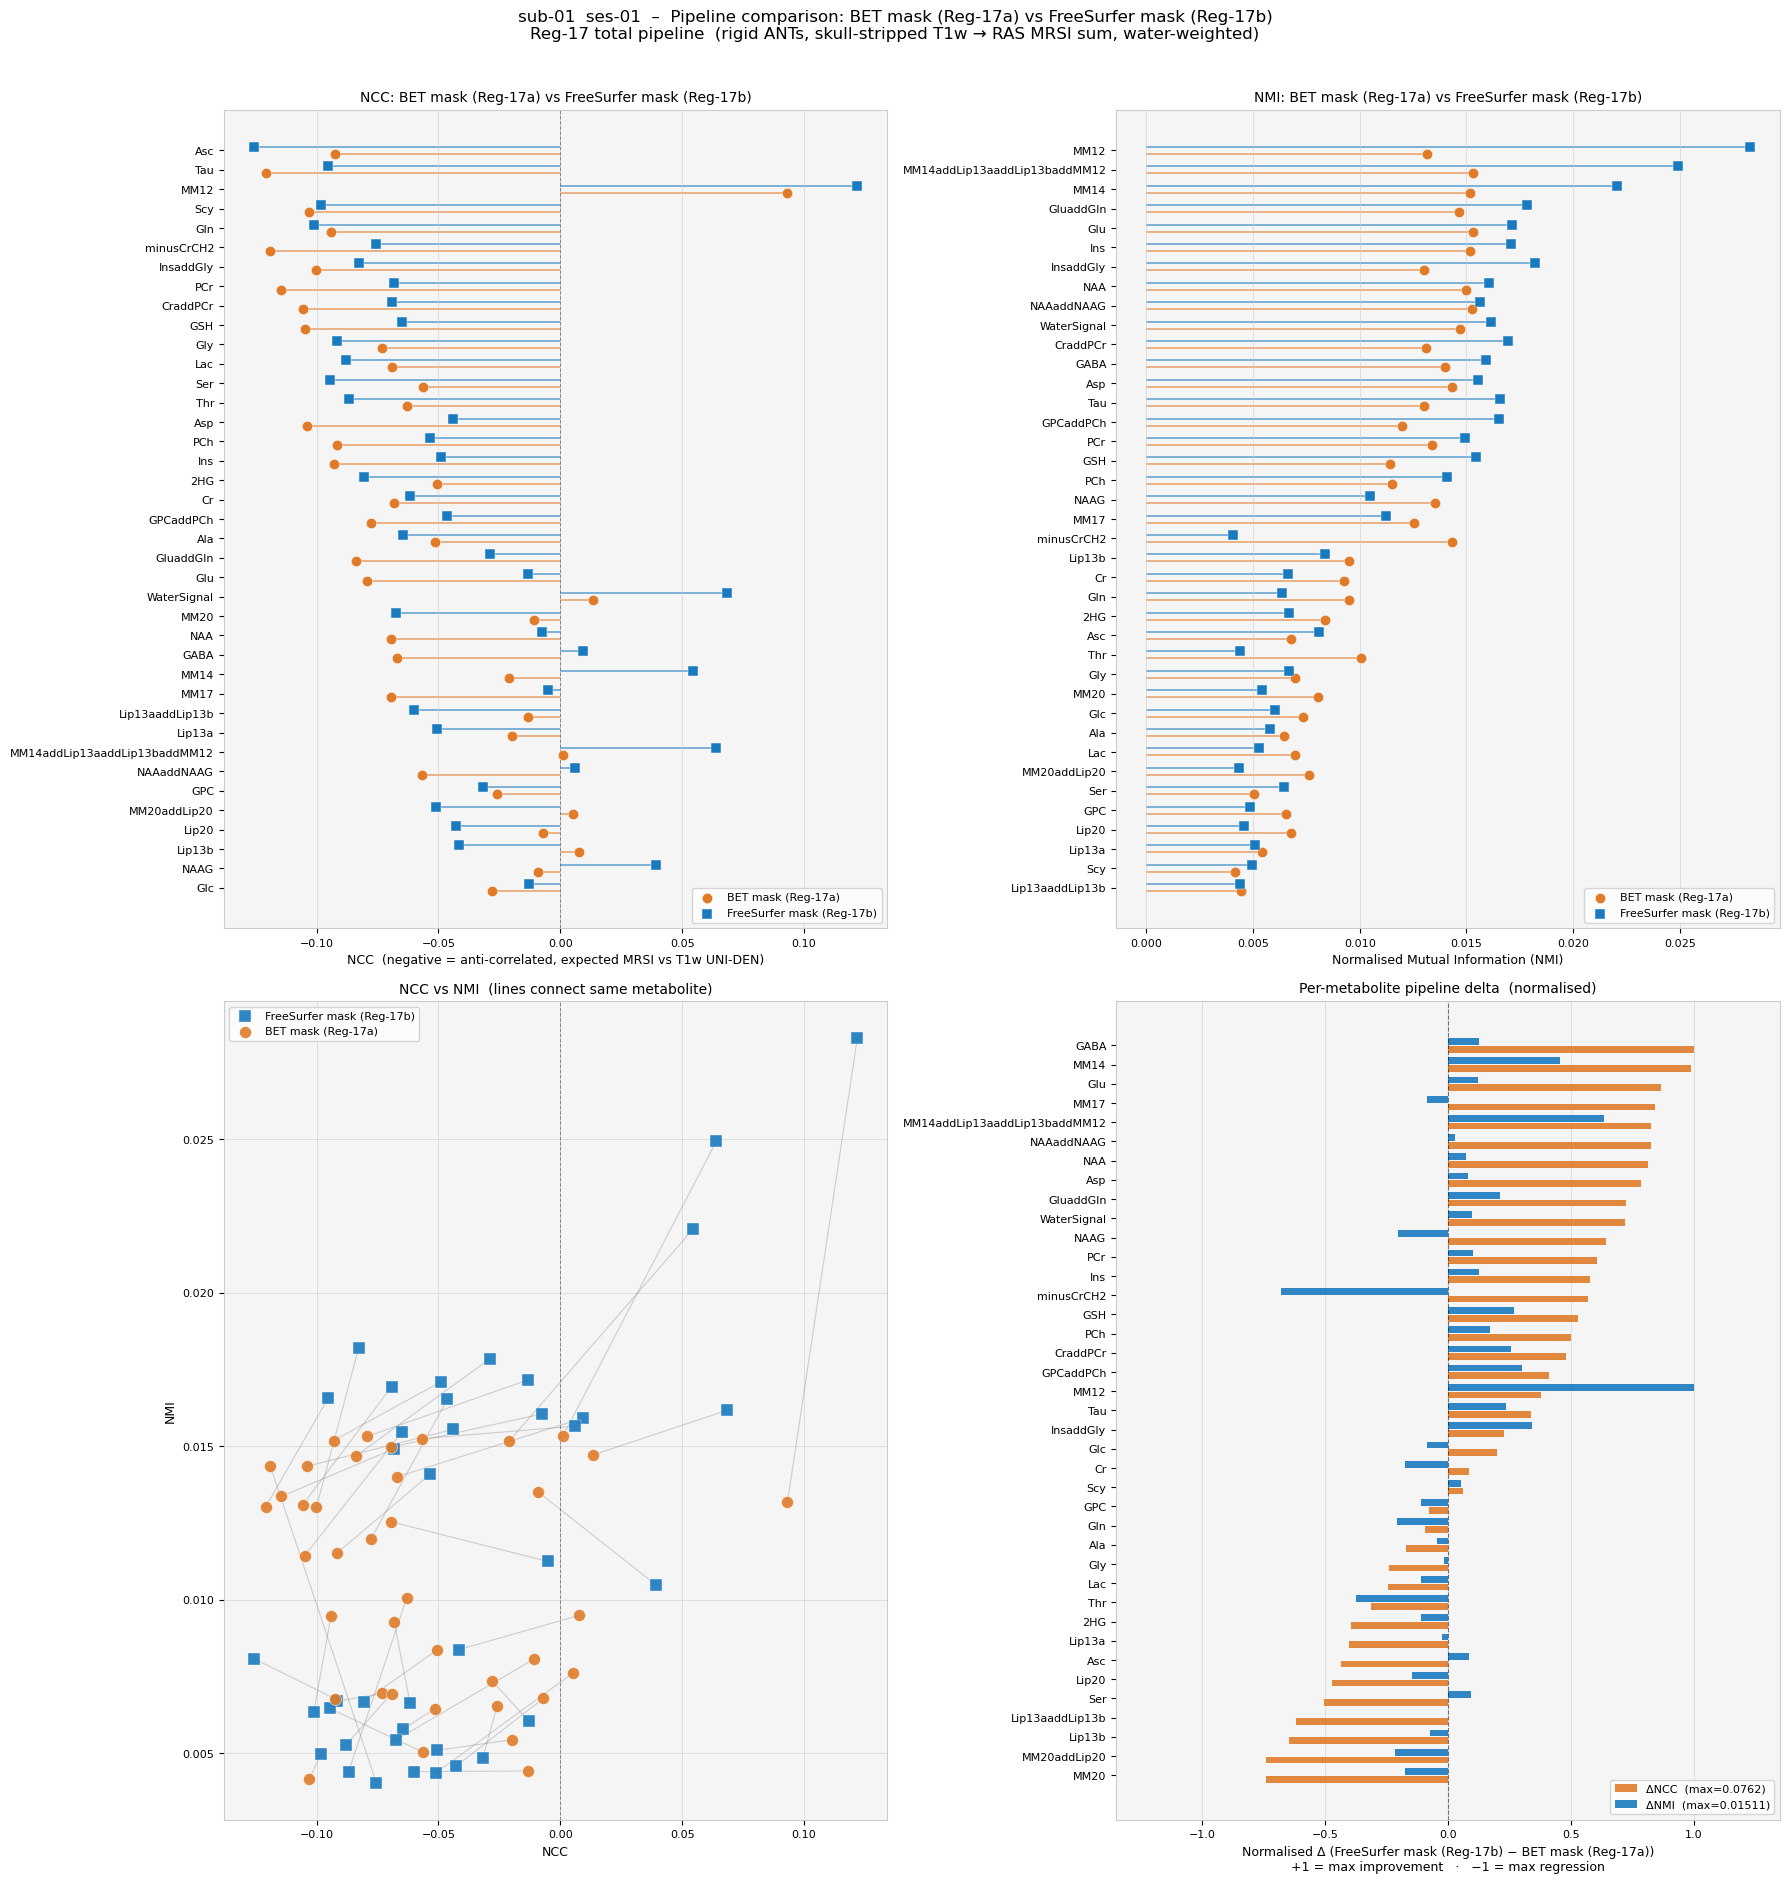


Label                                   NCC(A)     NCC(B)      ΔNCC     NMI(A)     NMI(B)      ΔNMI    SNR(A)    SNR(B)
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Asc                                    -0.0926    -0.1257   -0.0332     0.0068     0.0081   +0.0013     0.000     0.000
Tau                                    -0.1209    -0.0953   +0.0256     0.0130     0.0166   +0.0035     0.000     0.000
MM12                                    0.0931     0.1218   +0.0287     0.0132     0.0283   +0.0151     0.000     0.000
Scy                                    -0.1031    -0.0983   +0.0047     0.0042     0.0050   +0.0008     0.000     0.000
Gln                                    -0.0941    -0.1012   -0.0071     0.0095     0.0063   -0.0031     0.000     0.000
minusCrCH2                             -0.1190    -0.0755   +0.0434     0.0143     0.0040   -0.0103     0.000     0.000
InsaddGly                              

In [29]:
# 20b – Pipeline comparison: BET mask vs FreeSurfer mask (Reg-17a vs Reg-17b)

# Compare NCC, NMI and SNR metrics for every metabolite between the two
# final pipelines. Lines in the scatter panel connect the same metabolite
# across pipelines; the delta bar chart shows FreeSurfer − BET so that
# positive values mean the FreeSurfer mask produced better alignment.
plot_pipeline_metrics_comparison(
    metrics_a=metrics,
    metrics_b=metrics_freesurfer_mask,
    label_a="BET mask (Reg-17a)",
    label_b="FreeSurfer mask (Reg-17b)",
    subj=SUBJ,
    ses=SES,
)

## 20c – Interpretation of the registration quality plots

### Pipeline comparison: BET mask vs FreeSurfer mask

The comparison figure indicates that the FreeSurfer-mask pipeline performs better overall than the BET-mask pipeline.

- In the NCC panel, the FreeSurfer points are usually shifted to the right relative to BET, meaning higher NCC for most metabolites.
- In the **NMI panel**, the same pattern is visible and is even more convincing. This matters because **NMI is generally the more appropriate metric than NCC for cross-contrast alignment** such as T1w versus MRSI.
- In the **NCC vs NMI scatter**, many line pairs move up and to the right from BET to FreeSurfer, showing that the improvement is not isolated to one metric.
- In the **per-metabolite delta panel**, most normalized changes favor the FreeSurfer pipeline, although the size of the gain varies across metabolites.

Overall, the effect looks **systematic rather than incidental**. The moving-mask choice is influencing the quality of the final transform, and the FreeSurfer-derived mask appears to constrain the optimization more effectively than BET for this subject.

### Absolute quality of the final chosen pipeline

The second figure shows that even with the better pipeline, **registration quality is still heterogeneous across metabolites**.

- A few metabolites have clearly stronger NCC and NMI than the rest.
- Many metabolites cluster in a moderate or low range, which suggests that the transform is usable but not equally informative for every metabolite.
- Some metabolites still have NCC values near zero or below zero. That does **not automatically imply failure**, because NCC is sensitive to contrast mismatch and sparse support.
- The **NMI ranking is easier to trust here than NCC**, because it is less dependent on direct intensity correlation.

### Relation between SNR and alignment quality

The SNR-colored scatter plots show that high SNR does not guarantee better alignment metrics.

- Some high-SNR metabolites do align well, but not all of them.
- Some moderate-SNR metabolites still achieve reasonable NMI or NCC.
- This suggests that spatial/anatomical specificity matters at least as much as raw signal strength.



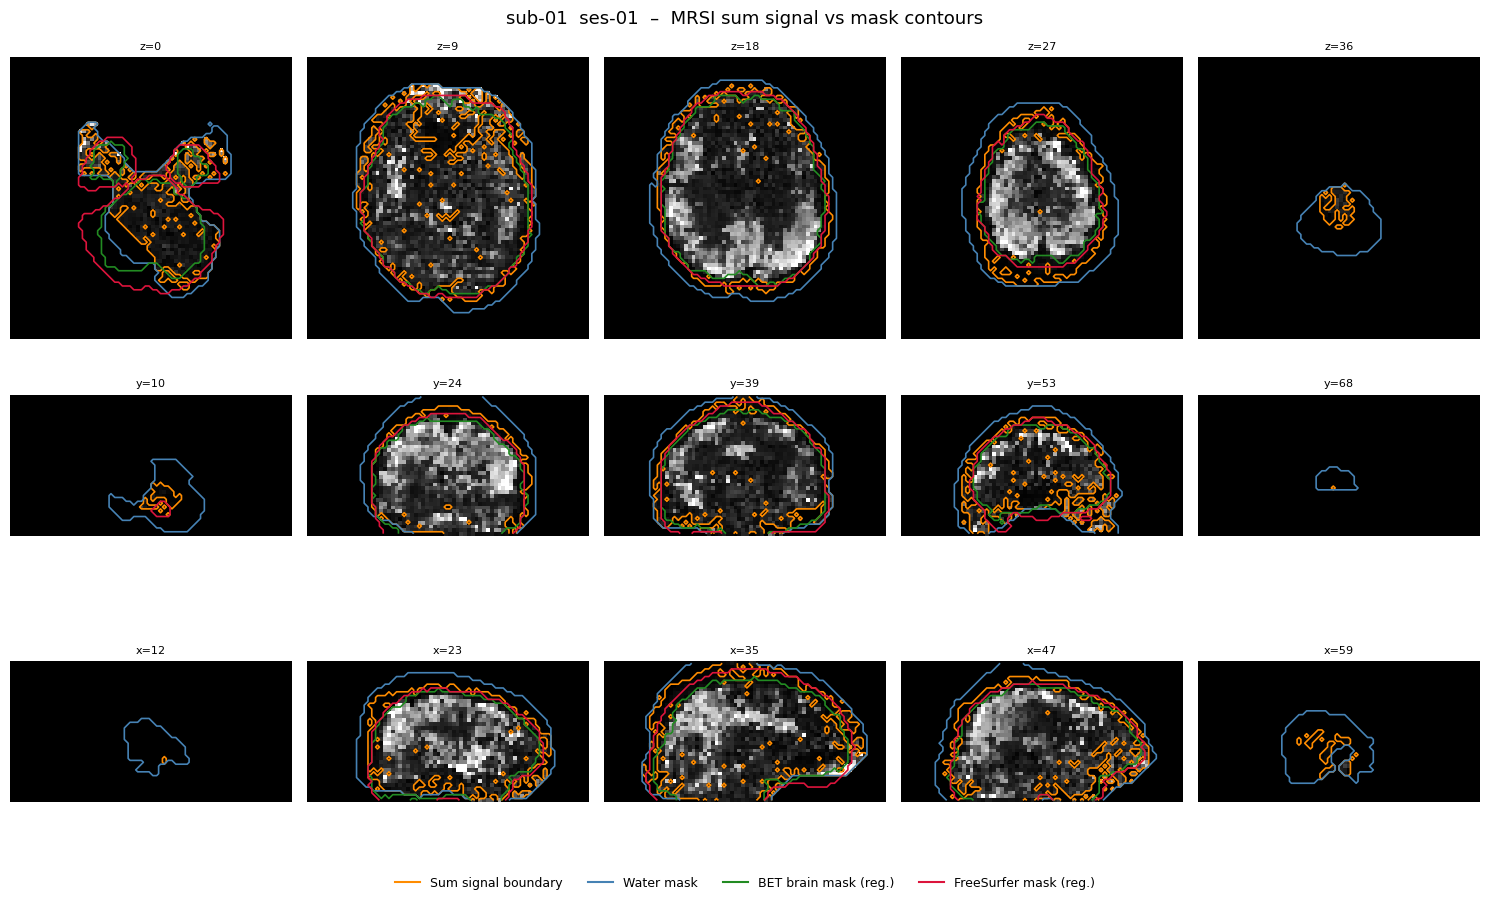

In [30]:


plot_mrsi_sum_mask_contours(
    sum_img=sum_img,
    water_mask_img=water_mask_img,
    bet_mask_img=bet_mask_reg_img,
    freesurfer_mask_img=freesurfer_mask_reg_img,
    subj=SUBJ,
    ses=SES,
)


/Users/user/FCBG_project_Connectome_registraction/Code/FCBG_project_Connectome_registraction/plot_utils.py:1771: UserWarning: kwargs['alpha']=0.55 detected in parameters.
Overriding with transparency=None.
To suppress this warning pass your 'alpha' value via the 'transparency' parameter.
  plotting.plot_stat_map(
/Users/user/FCBG_project_Connectome_registraction/Code/FCBG_project_Connectome_registraction/plot_utils.py:1816: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


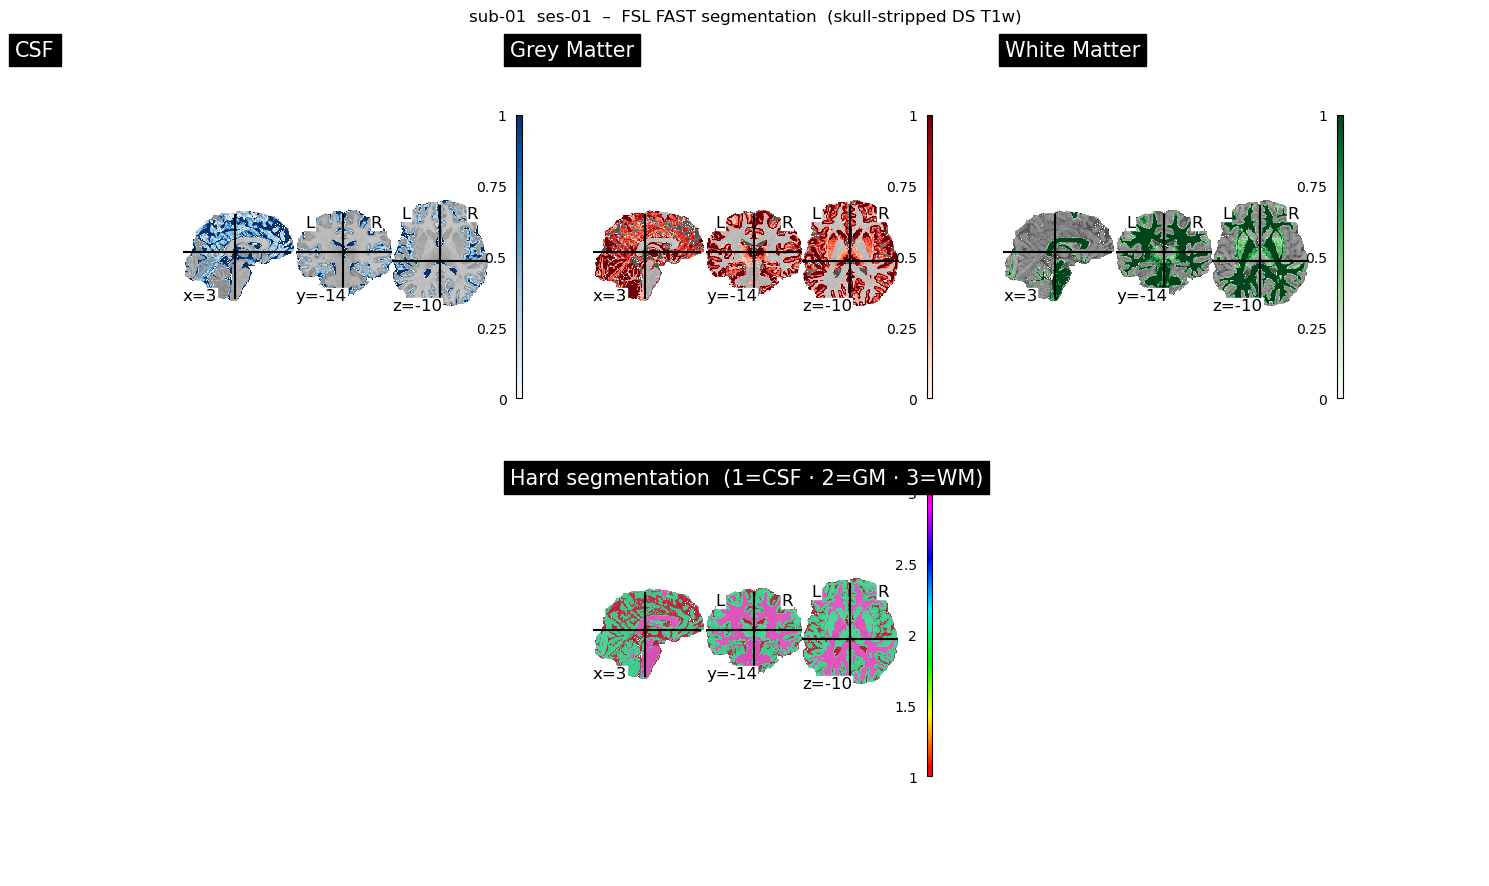


Tissue               Mean PVE   Volume (mL)
────────────────────────────────────────────
  CSF                   0.594        170.9 mL
  Grey Matter           0.718        525.6 mL
  White Matter          0.851        459.4 mL


In [31]:

plot_segmentation(
    t1w_img=t1w_brain_img,
    seg_imgs=seg_imgs,
    subj=SUBJ,
    ses=SES,
)


────────────────────────────────────────────────────
  Mask comparison  (registered → SUM_RAS grid)
────────────────────────────────────────────────────
  BET mask          :  1124.5 mL  ( 42794 vox)
  Water mask        :  1730.7 mL  ( 65865 vox)
  FreeSurfer mask   :  1272.5 mL  ( 48426 vox)
────────────────────────────────────────────────────
  BET ∩ Water       :   936.5 mL  ( 35640 vox)
  BET-only voxels   :   188.0 mL  (  7154 vox)
  Water-only voxels :   794.2 mL  ( 30225 vox)
  Dice  BET/Water      : 0.6560   Jaccard: 0.4881
  Dice  BET/FreeSurfer : 0.9372   Jaccard: 0.8818
  Dice  Water/FreeSurfer : 0.6877   Jaccard: 0.5241
  All-3 intersection :   935.7 mL  ( 35609 vox)
  FS-only voxels    :    52.3 mL  (  1990 vox)
  BET ≡ Water       : False
────────────────────────────────────────────────────

  ACTIVE mask for Reg 18 : sub-01_ses-01_acq-MRSIres_desc-BrainMask_T1w.nii.gz


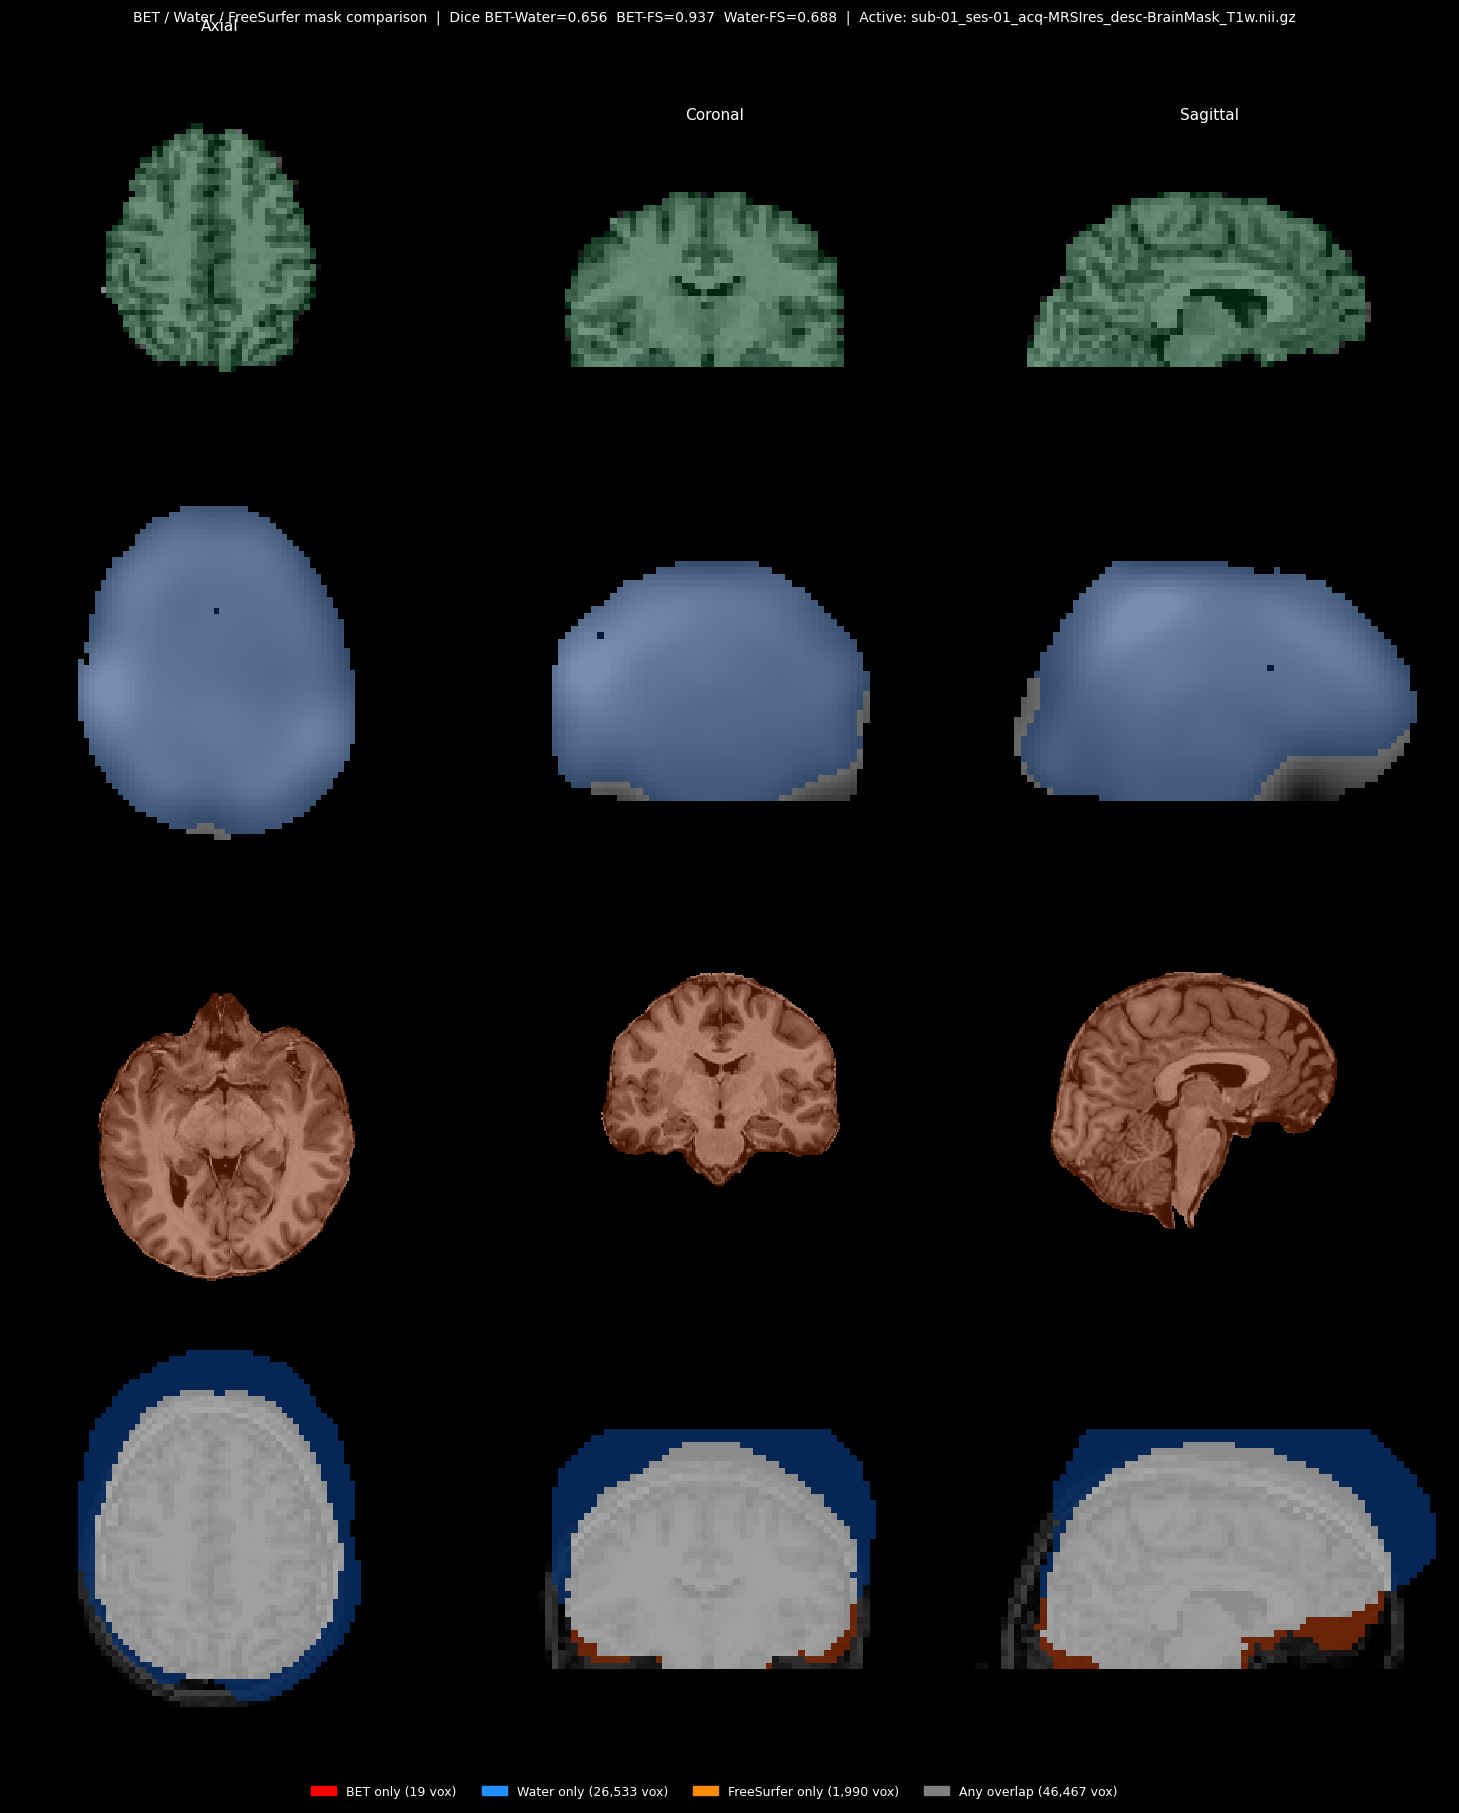

In [32]:
# Each mask is shown on the EXACT image it was extracted from:
#   BET row        -> BET skull-stripped DS T1w    (t1w_ds_brain_img)
#   Water row      -> raw water signal             (water_img)
#   FreeSurfer row -> SynthStrip skull-stripped T1w (FREESURFER_BRAIN_SRC_PATH)
#   Comparison row -> registered masks on full T1w (resampled internally)
_bet_native_mask = nib.load(T1W_BRAIN_MASK_DS_PATH)
_fs_mask_native  = nib.load(FREESURFER_MASK_SRC_PATH)
_fs_brain_bg     = nib.load(FREESURFER_BRAIN_SRC_PATH)

plot_mask_coverage_comparaison(
    bet_mask_img=bet_mask_reg_img,
    water_mask_img=water_mask_reg_img,
    extra_mask_img=freesurfer_mask_reg_img,
    t1w_ds_img=t1w_ds_img,
    bet_native_mask=_bet_native_mask,
    bet_bg_img=t1w_ds_brain_img,
    water_native_mask=water_mask_img,
    water_bg_img=water_img,
    extra_native_mask=_fs_mask_native,
    extra_bg_img=_fs_brain_bg,
    active_mask_name=T1W_BRAIN_MASK_DS_NAME)


In [33]:
#from main import atlas_imgs
#plot_atlas_segmentation(
#    t1w_img=t1w_brain_img,
#    atlas_imgs=atlas_imgs,
#    subj=SUBJ,
#    ses=SES)


## 21 – Tissue-based metabolite concentration metrics

Compares **GM/WM ratio** and **Brain/CSF ratio** per metabolite across three registration states:
- **Before**: raw MRSI resampled to T1w space (no registration)
- **Our pipeline**: Reg-17 (skull-stripped DS T1w → reoriented MRSI sum, water-weighted)
- **Article pipeline**: SyN (antsRegistrationSyN[sr], MRSI CrPCr → raw T1w)

Higher GM/WM ratio indicates better GM vs WM metabolite separation.  
Higher Brain/CSF ratio indicates less CSF contamination (good registration keeps signal within brain tissue).

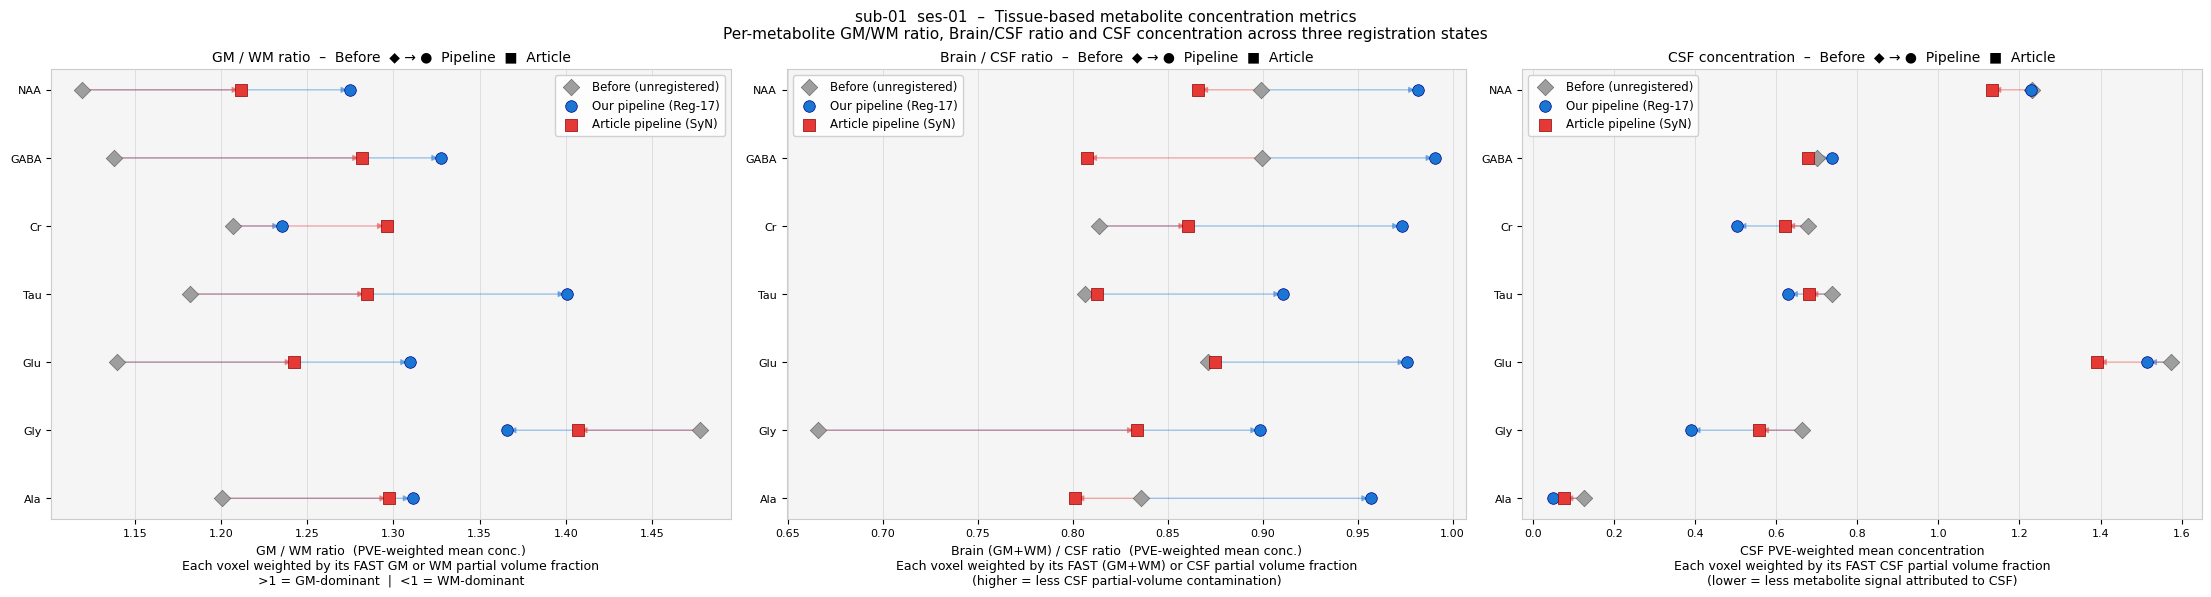

In [34]:
plot_tissue_metric_comparison(
    comparison_rows=tissue_metrics_comparison,
    metabolites=['Ala', 'Gly', 'Glu', 'Tau', 'Cr', 'GABA', 'NAA'],
    subj=SUBJ,
    ses=SES,
)


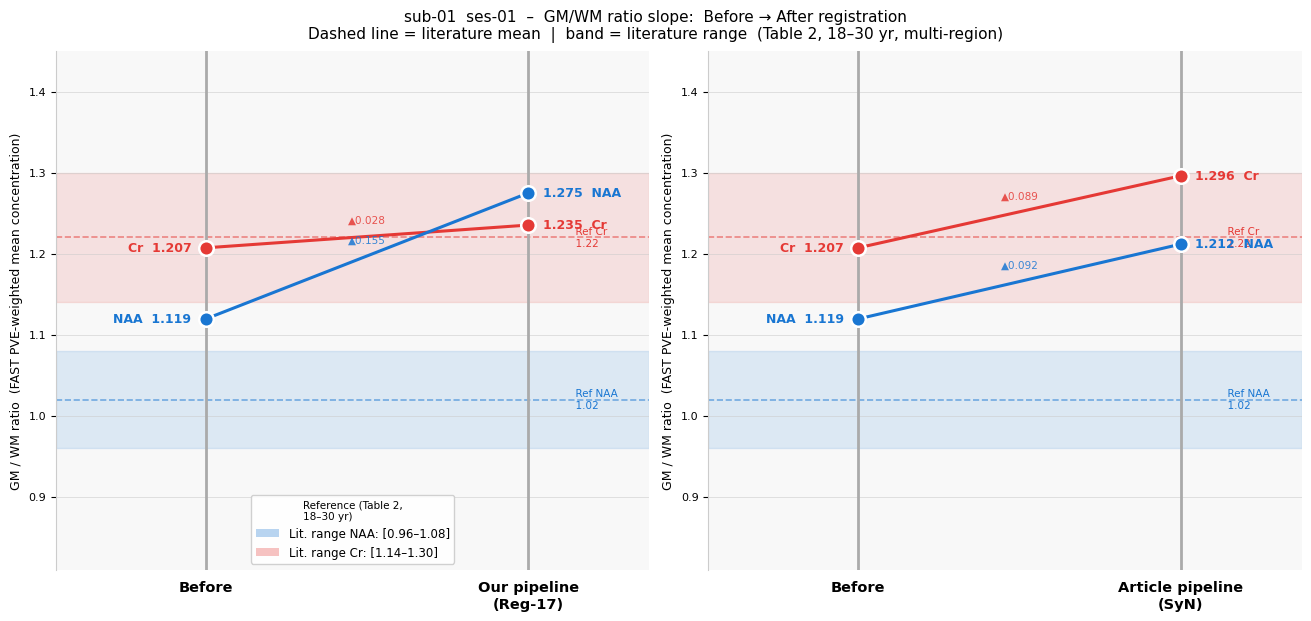

In [35]:
# Ground-truth GM/WM ratios from Table 2 (mean, lo, hi across 4 brain regions,
# 18-30 yr age group).  The 4 regional means (Frontal/Temporal/Parietal/Occipital)
# are averaged into a single whole-brain mean; the band is mean ± 1 SD across regions.
#
# NAA  regional means: [1.00, 1.11, 0.98, 1.00]  → mean=1.02, SD=0.06
# Cr   regional means: [1.17, 1.34, 1.17, 1.20]  → mean=1.22, SD=0.08
_REF_GM_WM = {
    'NAA': (1.02, 0.96, 1.08),  # mean=1.02  ±1 SD across regions [0.96–1.08]
    'Cr':  (1.22, 1.14, 1.30),  # mean=1.22  ±1 SD across regions [1.14–1.30]
}

plot_tissue_slope_comparison(
    comparison_rows=tissue_metrics_comparison,
    metabolites=['NAA', 'Cr'],
    reference_gm_wm=_REF_GM_WM,
    subj=SUBJ,
    ses=SES,
)
